In [1]:
# 데이터 확인하기 2025.11.19
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [2]:
# 원본 데이터 불러오기
df = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

In [3]:
remove_cols = pd.read_csv('../doc/remove_cols.xls', header=0).squeeze()
df.drop(columns=remove_cols, axis=1, inplace=True)
df.drop(columns=['ID', 'TARGET'], axis=1, inplace=True) # train 데이터 ID와 TARGET 모두 제거
df.columns

Index(['var3', 'var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1',
       'imp_op_var39_comer_ult3', 'imp_op_var41_comer_ult1',
       'imp_op_var41_comer_ult3', 'imp_op_var41_efect_ult1',
       'imp_op_var41_efect_ult3', 'imp_op_var41_ult1',
       ...
       'saldo_medio_var8_ult3', 'saldo_medio_var12_hace2',
       'saldo_medio_var12_hace3', 'saldo_medio_var12_ult1',
       'saldo_medio_var12_ult3', 'saldo_medio_var13_corto_hace2',
       'saldo_medio_var13_corto_hace3', 'saldo_medio_var13_corto_ult1',
       'saldo_medio_var13_corto_ult3', 'var38'],
      dtype='object', length=149)

In [1]:
remove_cols_test = pd.read_csv('../doc/remove_cols.xls', header=0).squeeze()
df_test.drop(columns=remove_cols, axis=1, inplace=True)
df_test.drop(columns=['ID'], axis=1, inplace=True) # test 데이터 ID와 TARGET 모두 제거

NameError: name 'pd' is not defined

In [ ]:
print(df.shape) # (76020, 154)
desc = df.describe()
desc.to_csv('../data/df_describe_after_removed_cols.csv')
desc.loc['min']

(76020, 149)


var3                            -999999.00
var15                                 5.00
imp_ent_var16_ult1                    0.00
imp_op_var39_comer_ult1               0.00
imp_op_var39_comer_ult3               0.00
                                   ...    
saldo_medio_var13_corto_hace2         0.00
saldo_medio_var13_corto_hace3         0.00
saldo_medio_var13_corto_ult1          0.00
saldo_medio_var13_corto_ult3          0.00
var38                              5163.75
Name: min, Length: 149, dtype: float64

In [ ]:
print(df_test.shape) # (76020, 154)
desc = df_test.describe()
desc.to_csv('../data/df_describe_after_removed_cols.csv')
desc.loc['min']

In [5]:
# 3. IQR 기반 이상치 기준 계산
Q1 = desc.loc["25%"]
Q3 = desc.loc["75%"]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [ ]:
# 이상치 마스킹 (컬럼별로)
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.select_dtypes(include="number").columns:
    if col in lower_bound.index:
        lb = lower_bound[col]
        ub = upper_bound[col]
        outlier_mask[col] = (df[col] < lb) | (df[col] > ub)

# 5. 이상치 기준 + 마스크를 outlier_bounds에 통합
outlier_bounds = pd.DataFrame({
    "min" : desc.loc['min'],
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "max": desc.loc['max'],
    "LowerBound": lower_bound,
    "UpperBound": upper_bound,
    "OutlierCount": outlier_mask.sum()
})

print(outlier_bounds)


In [ ]:
# 이상치 마스킹 (컬럼별로) -- test
outlier_mask = pd.DataFrame(False, index=df_test.index, columns=df_test.columns)

for col in df_test.select_dtypes(include="number").columns:
    if col in lower_bound.index:
        lb = lower_bound[col]
        ub = upper_bound[col]
        outlier_mask[col] = (df_test[col] < lb) | (df_test[col] > ub)

# 5. 이상치 기준 + 마스크를 outlier_bounds에 통합
outlier_bounds = pd.DataFrame({
    "min" : desc.loc['min'],
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "max": desc.loc['max'],
    "LowerBound": lower_bound,
    "UpperBound": upper_bound,
    "OutlierCount": outlier_mask.sum()
})

print(outlier_bounds)


                                     min          Q1           Q3       IQR  \
var3                          -999999.00      2.0000       2.0000      0.00   
var15                               5.00     23.0000      40.0000     17.00   
imp_ent_var16_ult1                  0.00      0.0000       0.0000      0.00   
imp_op_var39_comer_ult1             0.00      0.0000       0.0000      0.00   
imp_op_var39_comer_ult3             0.00      0.0000       0.0000      0.00   
...                                  ...         ...          ...       ...   
saldo_medio_var13_corto_hace2       0.00      0.0000       0.0000      0.00   
saldo_medio_var13_corto_hace3       0.00      0.0000       0.0000      0.00   
saldo_medio_var13_corto_ult1        0.00      0.0000       0.0000      0.00   
saldo_medio_var13_corto_ult3        0.00      0.0000       0.0000      0.00   
var38                            5163.75  67870.6125  118756.2525  50885.64   

                                       max  LowerBo

In [7]:
# 데이터 전처리 : 
# 1. var3 feature -> -999999 -> 최빈값인 2로 대체
print(df.var3.value_counts())
df['var3'] = df['var3'].replace(-999999 , 2, inplace=False) # False 변경된 내용 변환

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
           ...  
 63            1
 194           1
 40            1
 57            1
 87            1
Name: count, Length: 208, dtype: int64


In [ ]:
# 데이터 전처리 : 
# 1. var3 feature -> -999999 -> 최빈값인 2로 대체
print(df_test.var3.value_counts())
df_test['var3'] = df_test['var3'].replace(-999999 , 2, inplace=False) # False 변경된 내용 변환

In [8]:
df.describe()

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,...,saldo_medio_var8_ult3,saldo_medio_var12_hace2,saldo_medio_var12_hace3,saldo_medio_var12_ult1,saldo_medio_var12_ult3,saldo_medio_var13_corto_hace2,saldo_medio_var13_corto_hace3,saldo_medio_var13_corto_ult1,saldo_medio_var13_corto_ult3,var38
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,7.602000e+04,76020.000000,7.602000e+04,7.602000e+04,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04
mean,2.716483,33.212865,86.208265,72.363067,119.529632,68.803937,113.056934,68.205140,113.225058,137.242763,...,110.026575,3.997023e+03,613.534443,5.703008e+03,4.401002e+03,3639.419939,556.184178,4852.261814,3857.848542,1.172358e+05
std,9.447971,12.956486,1614.757313,339.315831,546.266294,319.605516,512.154823,531.897917,950.086398,697.712596,...,1935.305713,3.777314e+04,9292.752726,4.620254e+04,3.550718e+04,26359.174223,7182.642532,31886.615189,25572.245055,1.826646e+05
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1844.520000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,5.163750e+03
25%,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,6.787061e+04
50%,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.064092e+05
75%,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.187563e+05
max,238.000000,105.000000,210000.000000,12888.030000,21024.810000,12888.030000,16566.810000,45990.000000,131100.000000,47598.090000,...,177582.000000,3.000538e+06,668335.320000,3.004186e+06,2.272859e+06,450000.000000,304838.700000,450000.000000,450000.000000,2.203474e+07


In [9]:
outlier_bounds.to_csv('../data/outlier_bounds_154cols.csv')

In [11]:
from matplotlib import rc

plt.rc('font', family='Malgun Gothic')

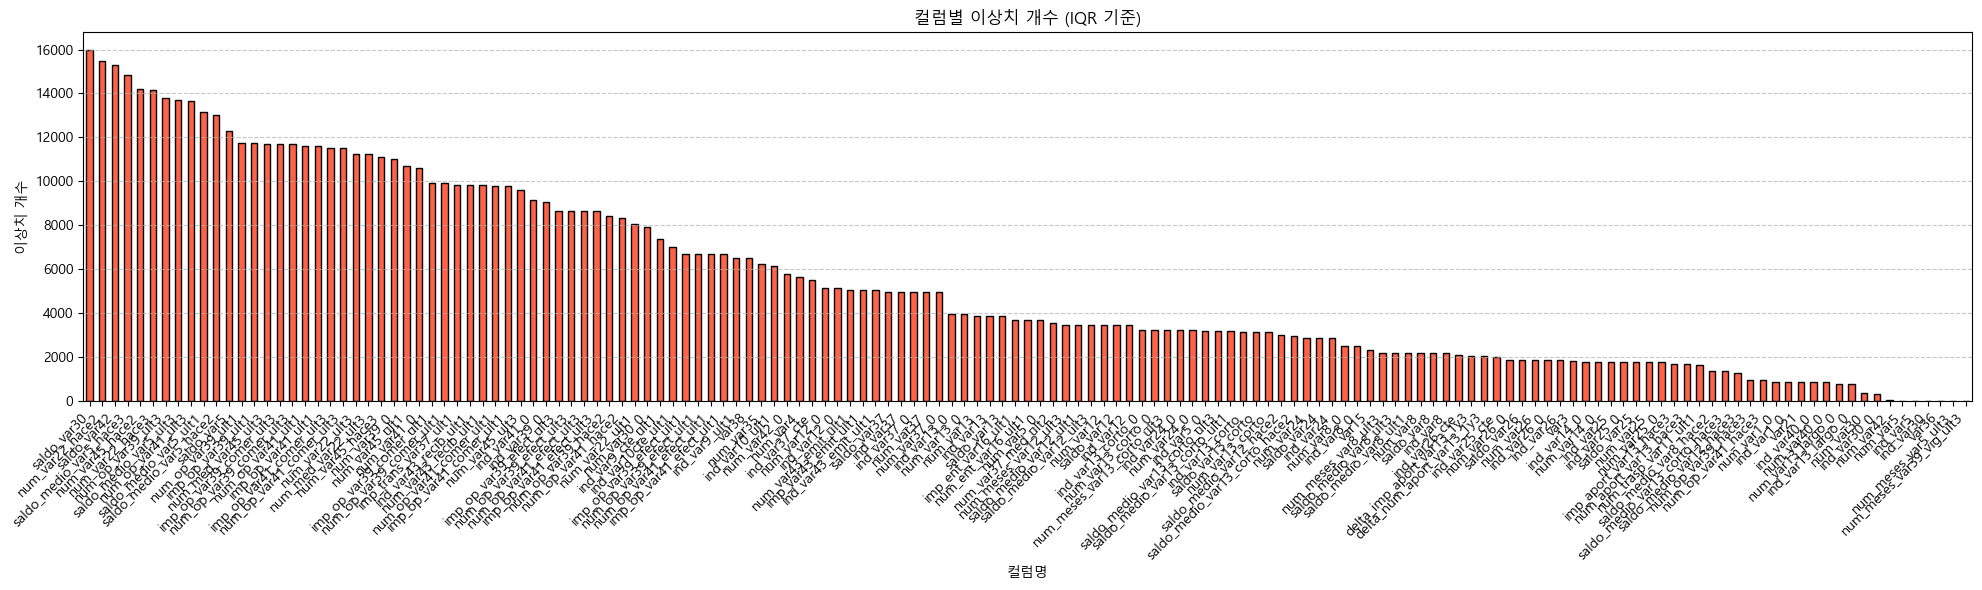

In [12]:
# 시각화
outlier_series = outlier_bounds['OutlierCount'].sort_values(ascending=False)

plt.figure(figsize=(20, 6))
outlier_series.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("컬럼별 이상치 개수 (IQR 기준)")
plt.ylabel("이상치 개수")
plt.xlabel("컬럼명")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
print(outlier_series[outlier_series > 0], outlier_series[outlier_series > 10], outlier_series[outlier_series > 50], outlier_series[outlier_series > 100])
# 0 보다 큰  147
# 10 보다 큰 146개
# 50 보다 큰 145개
# 100 보다 큰 145

saldo_var30               15983
num_var22_hace2           15479
saldo_var42               15281
saldo_medio_var5_hace3    14864
num_var45_hace2           14196
                          ...  
ind_var13_largo_0           773
num_var30                   357
ind_var30_0                 343
num_var42                    36
num_var5                      4
Name: OutlierCount, Length: 144, dtype: int64 saldo_var30               15983
num_var22_hace2           15479
saldo_var42               15281
saldo_medio_var5_hace3    14864
num_var45_hace2           14196
                          ...  
num_var13_largo_0           773
ind_var13_largo_0           773
num_var30                   357
ind_var30_0                 343
num_var42                    36
Name: OutlierCount, Length: 143, dtype: int64 saldo_var30               15983
num_var22_hace2           15479
saldo_var42               15281
saldo_medio_var5_hace3    14864
num_var45_hace2           14196
                          ...  
num_var40_0 

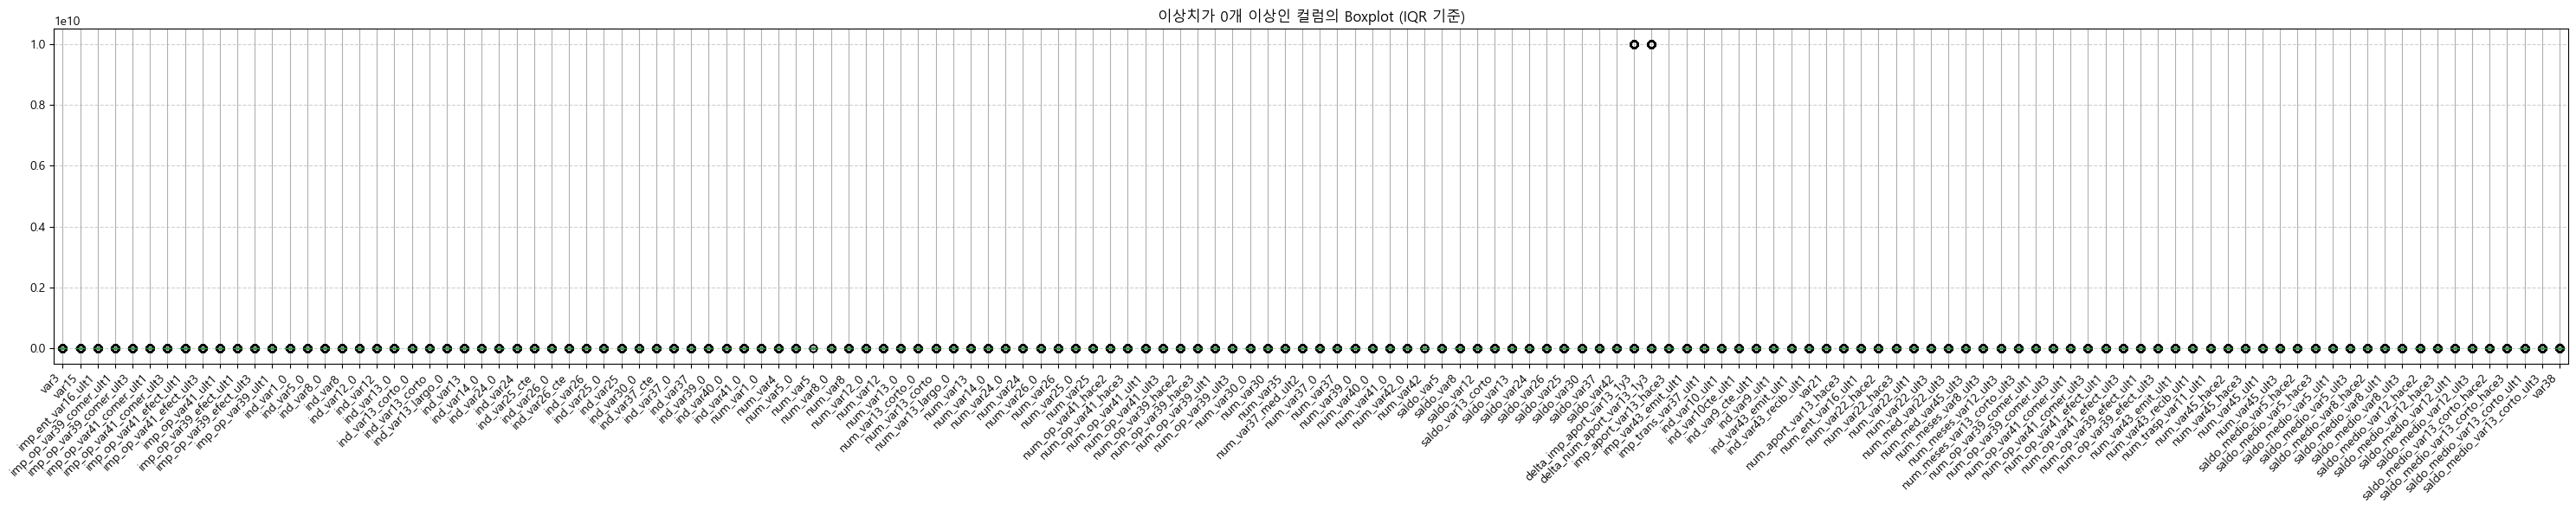

In [14]:
# 5. 이상치가 n개 이상인 컬럼만 필터링
ncnt = 0
selected_cols = outlier_bounds[outlier_bounds["OutlierCount"] > ncnt].index.tolist()

# 6. Boxplot 시각화
plt.figure(figsize=(30, 6))
df[selected_cols].boxplot()
plt.title(f"이상치가 {ncnt}개 이상인 컬럼의 Boxplot (IQR 기준)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


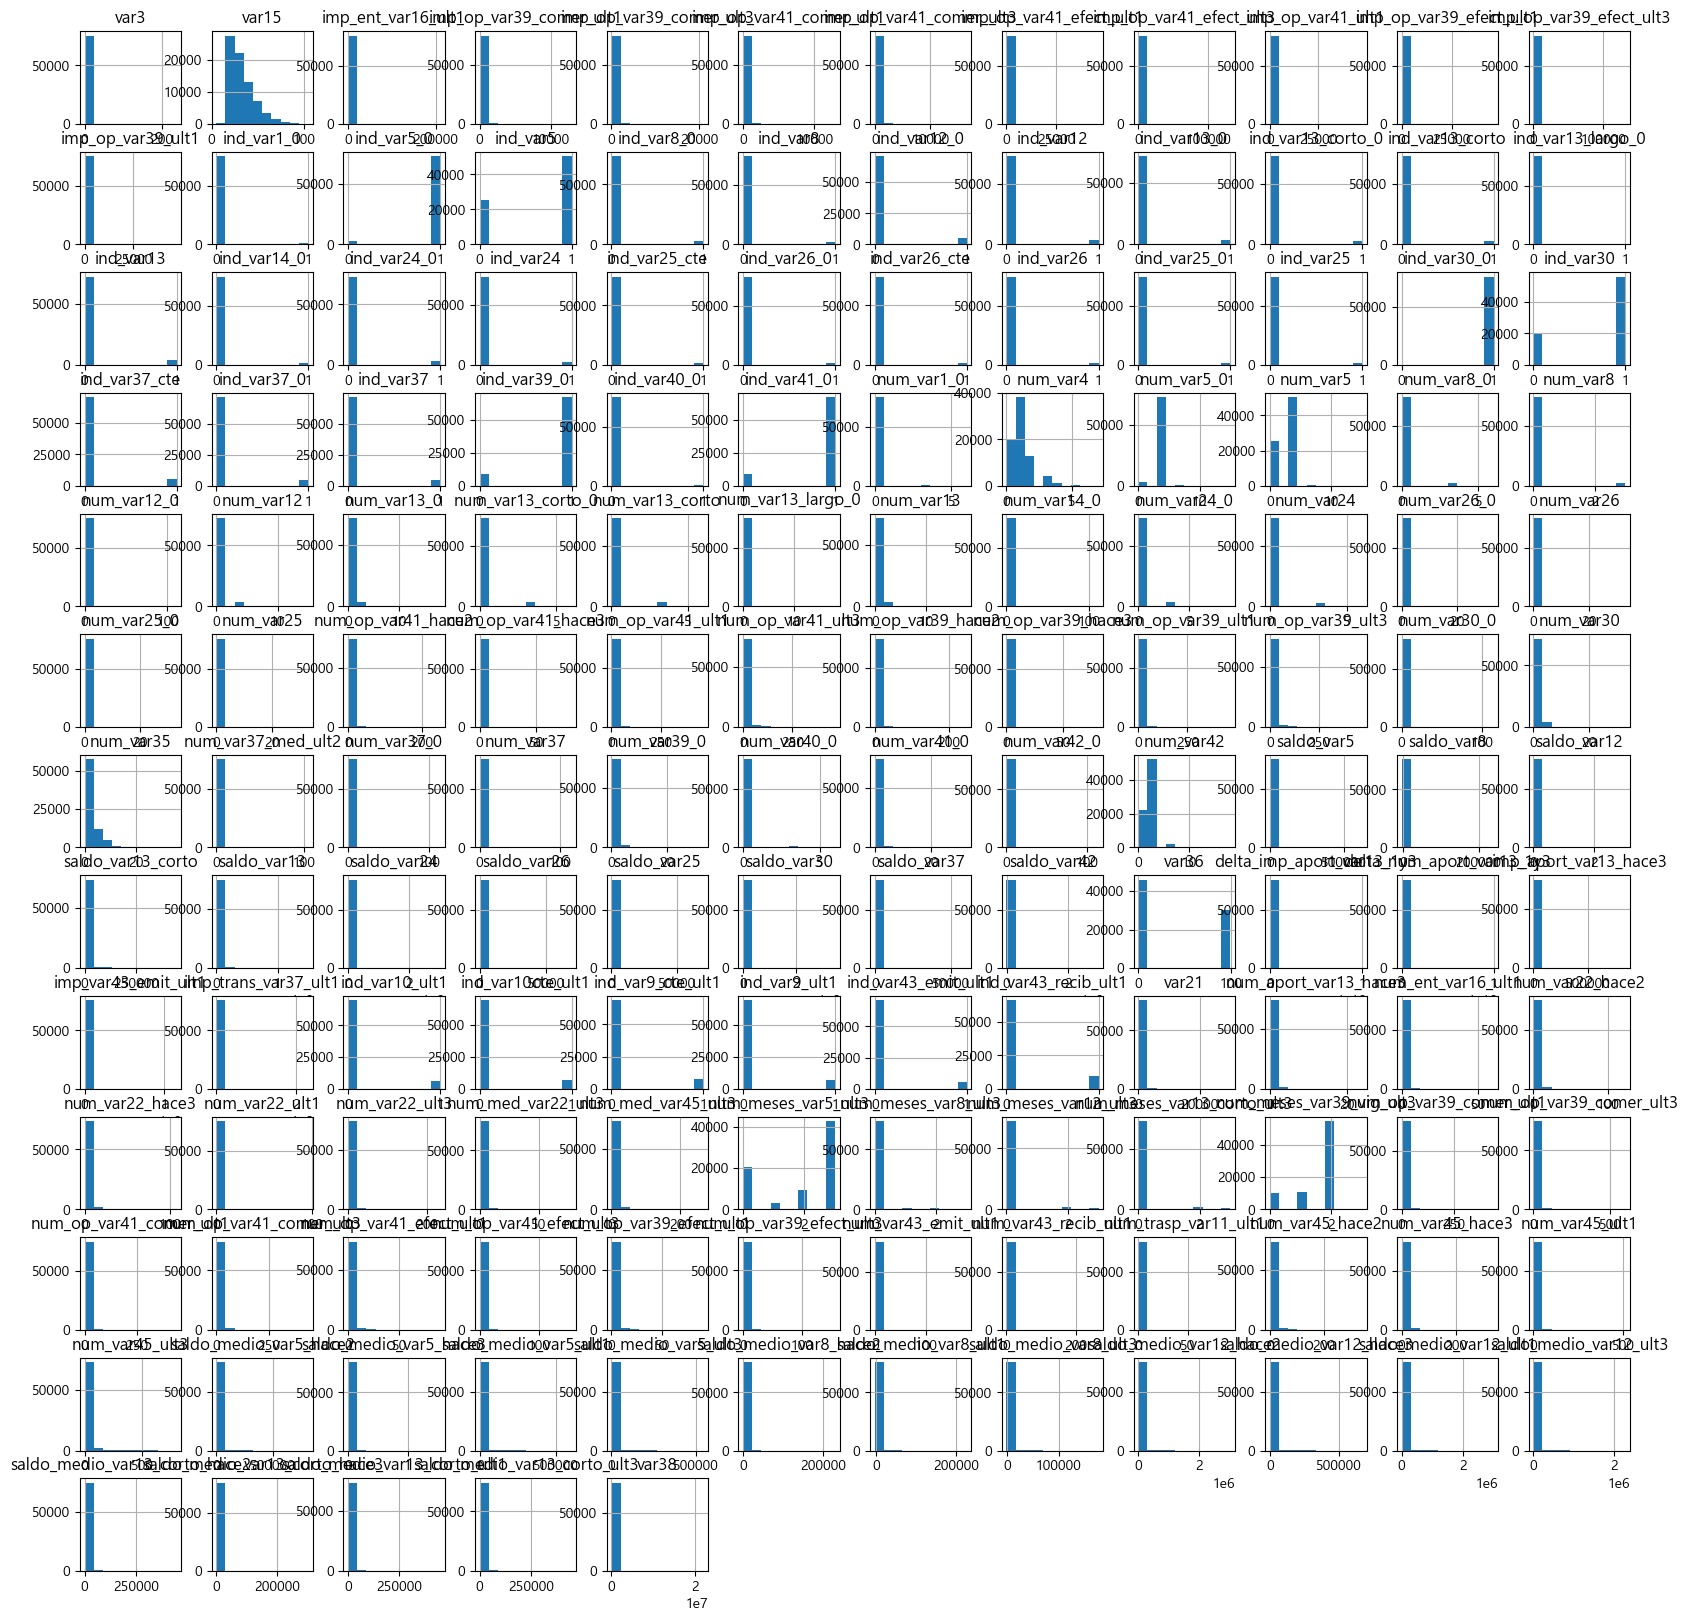

In [15]:
df.hist(figsize=(20, 20))
plt.show()

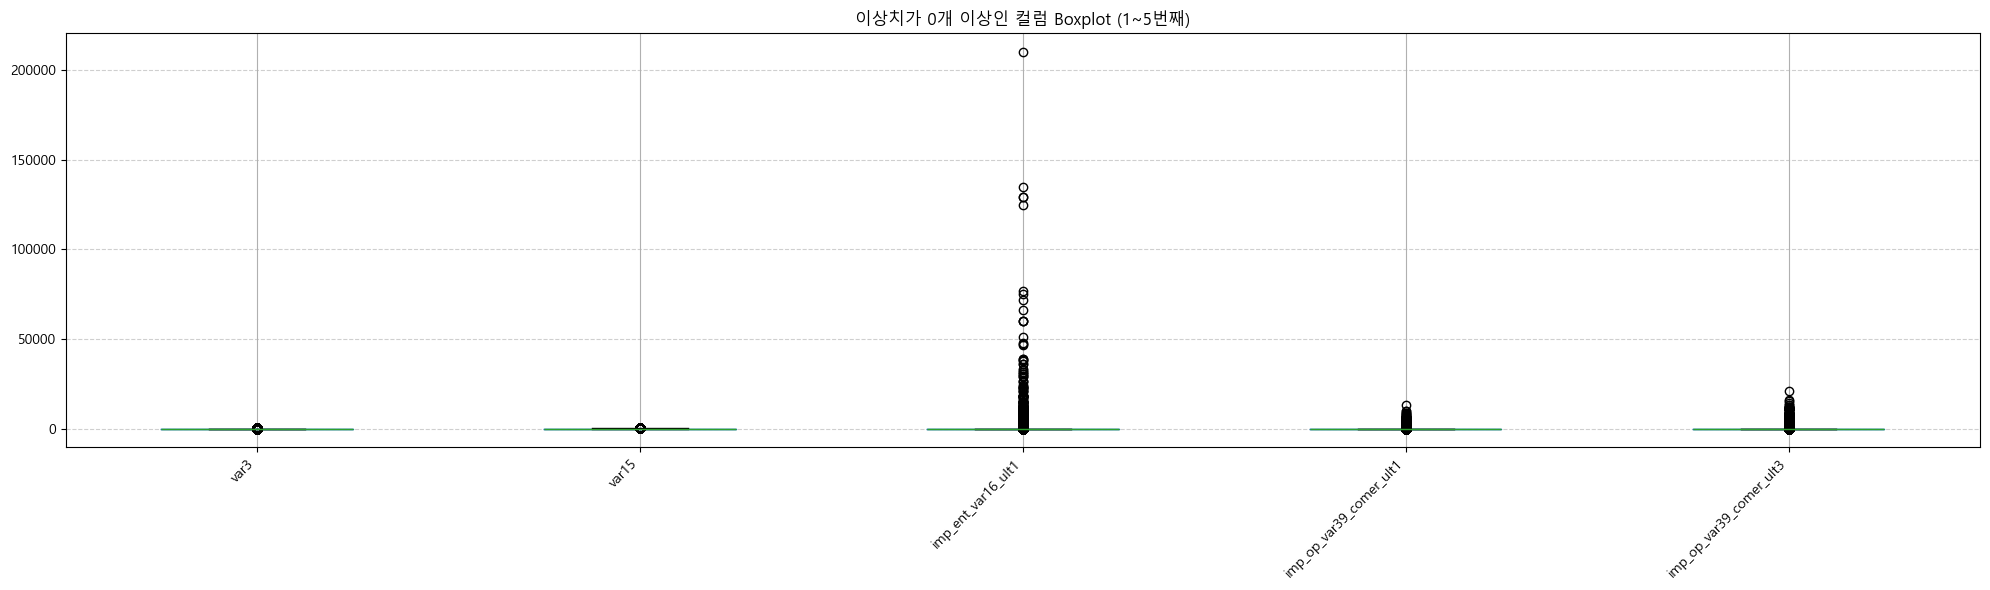

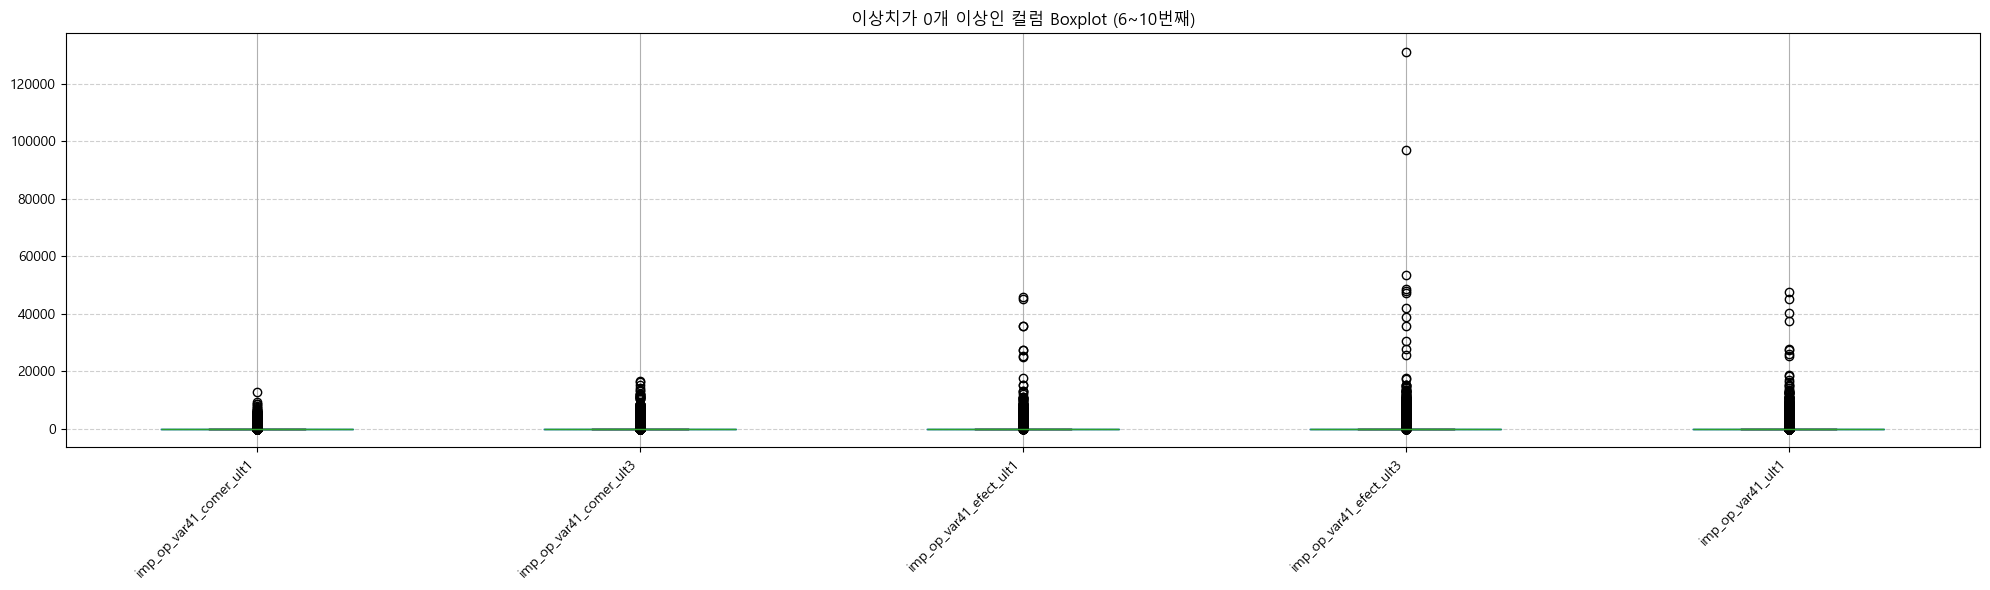

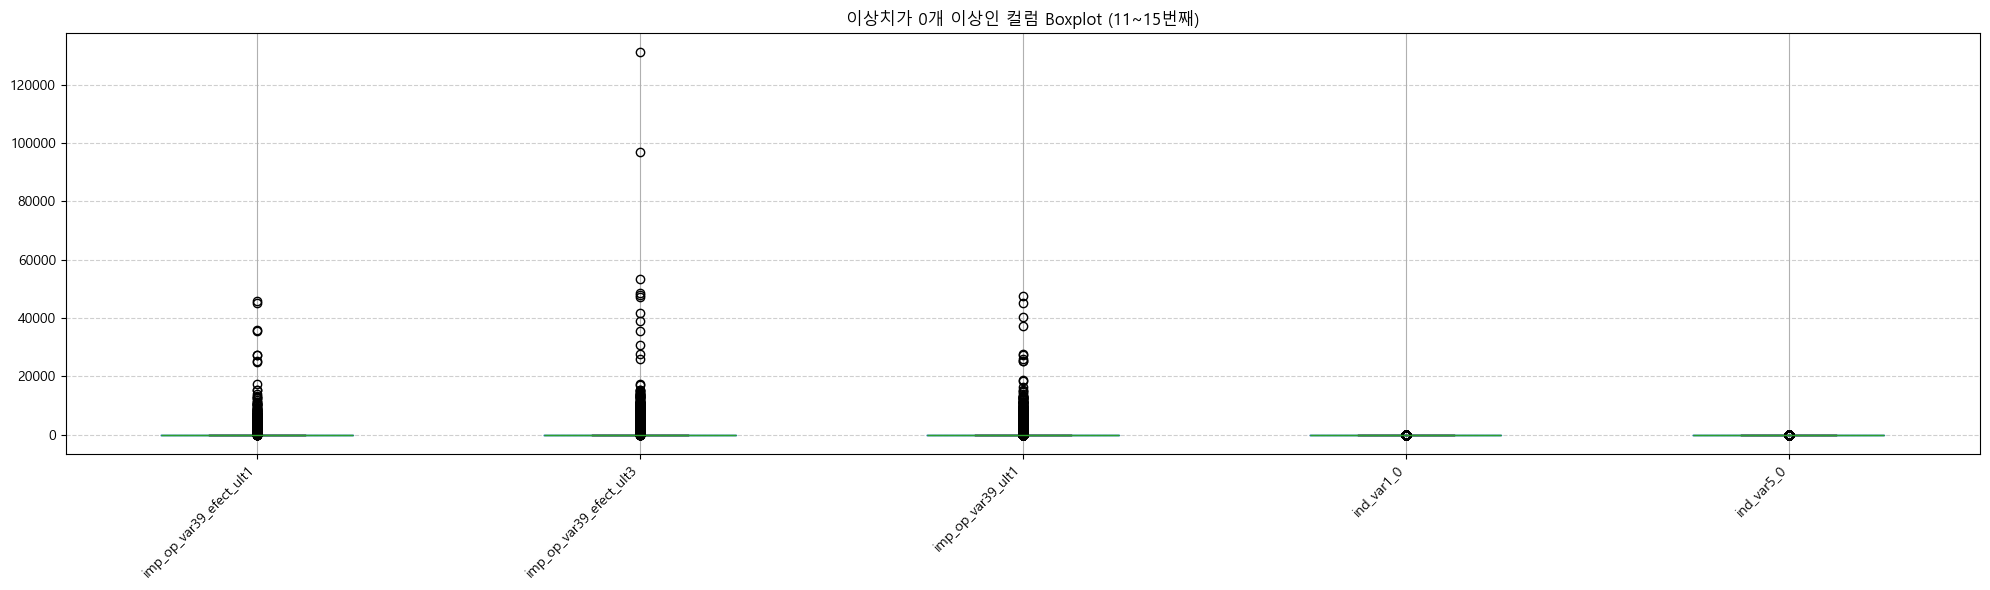

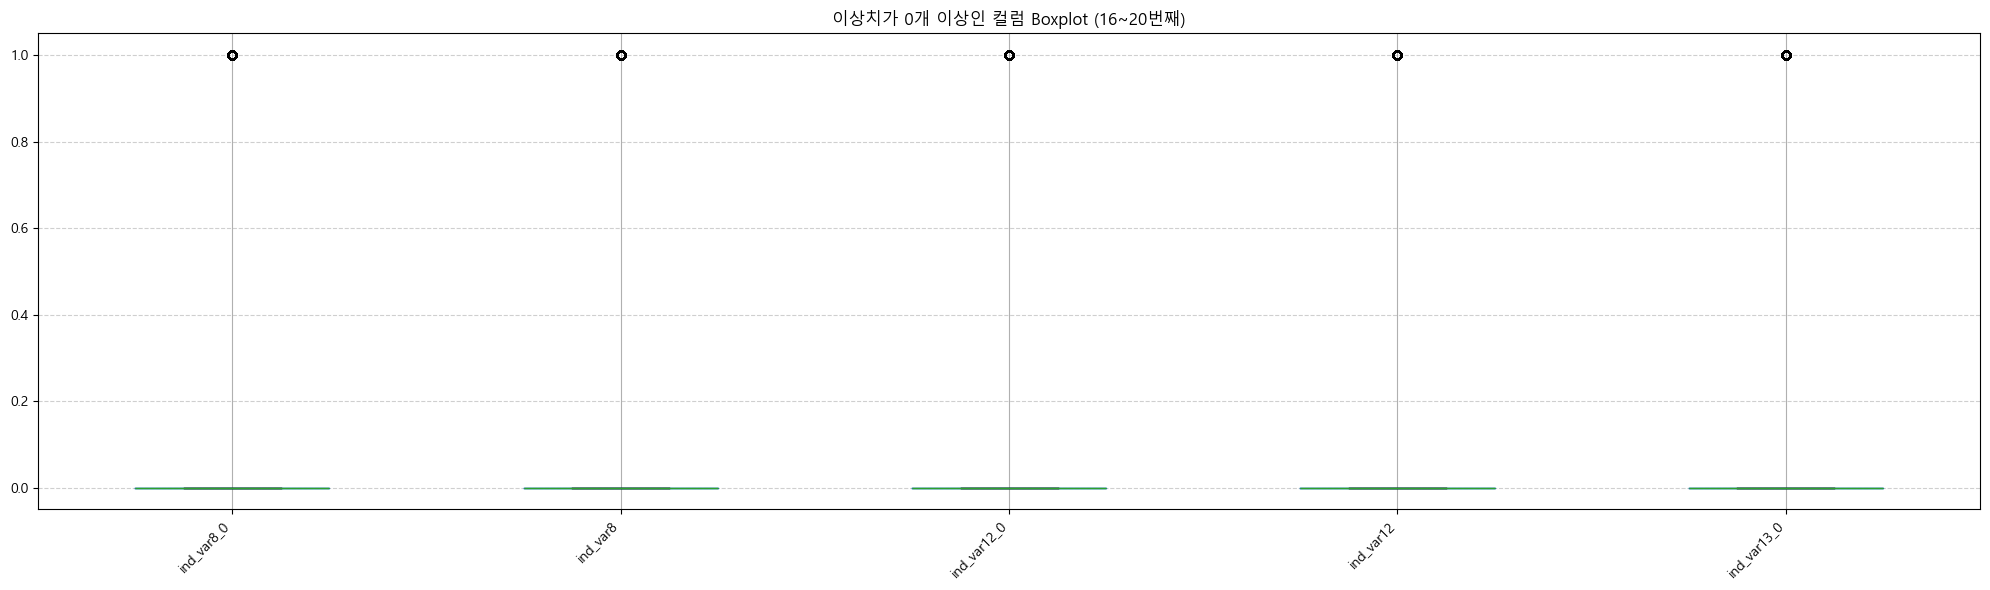

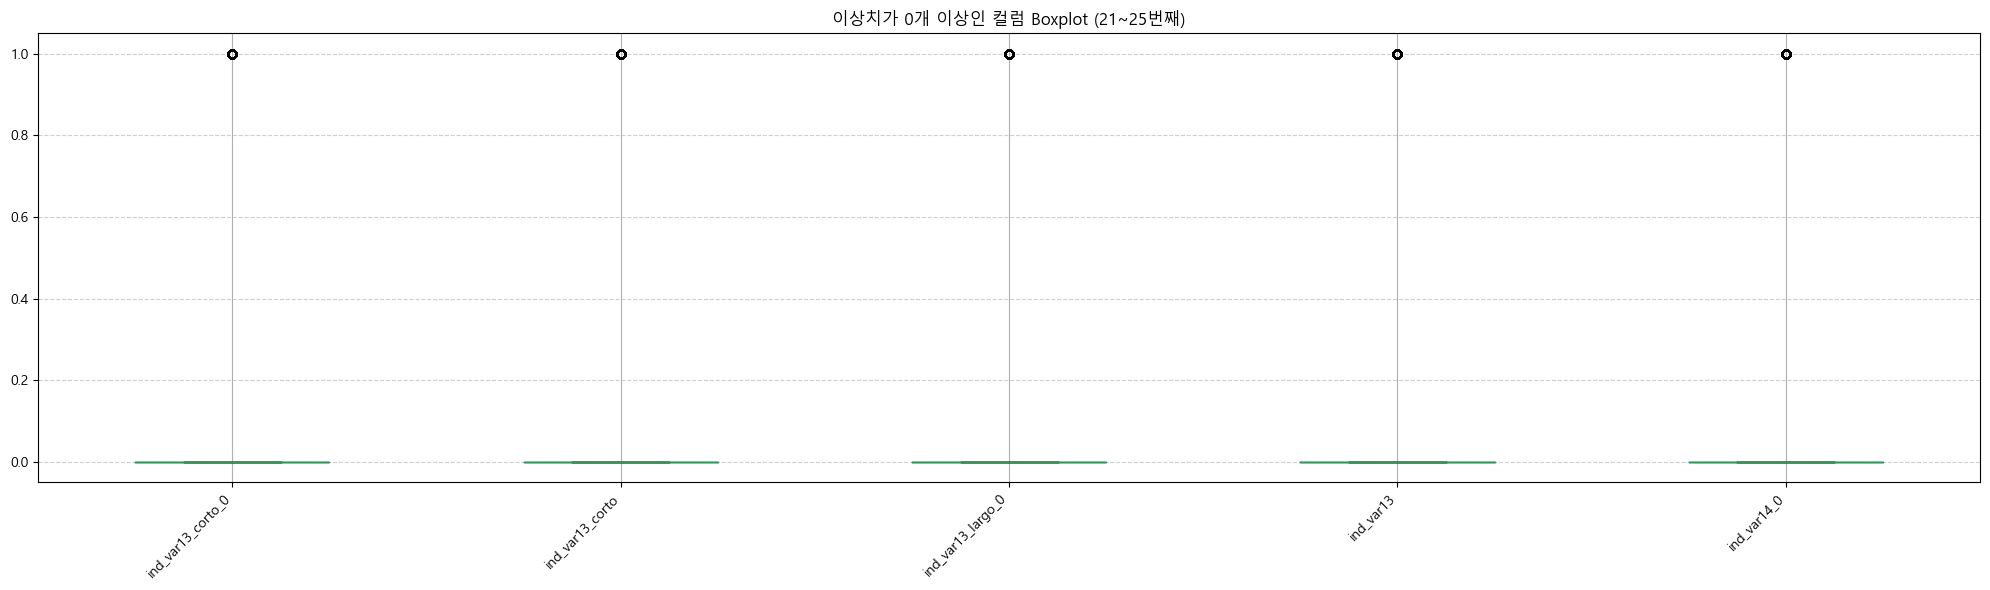

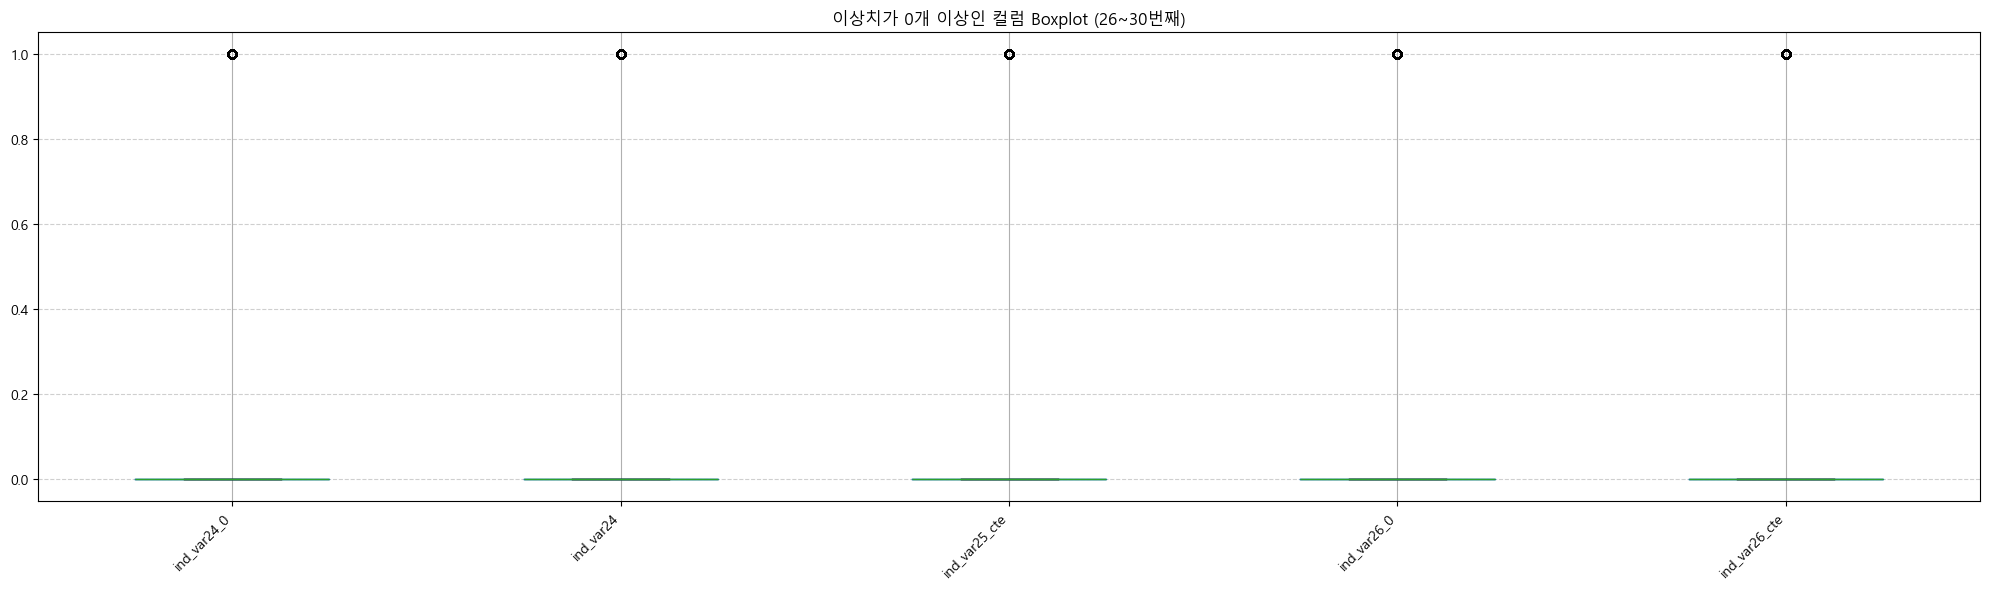

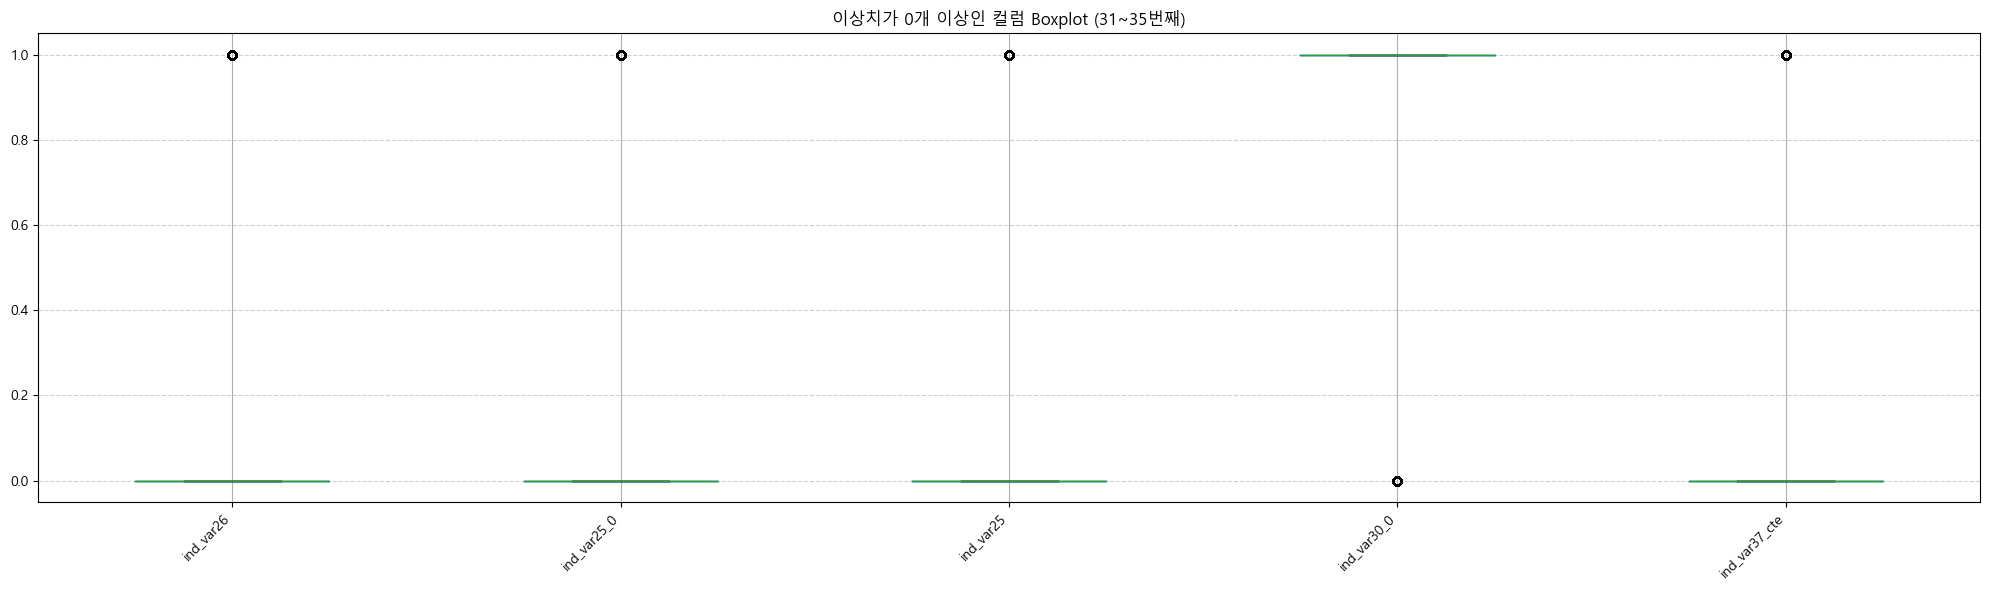

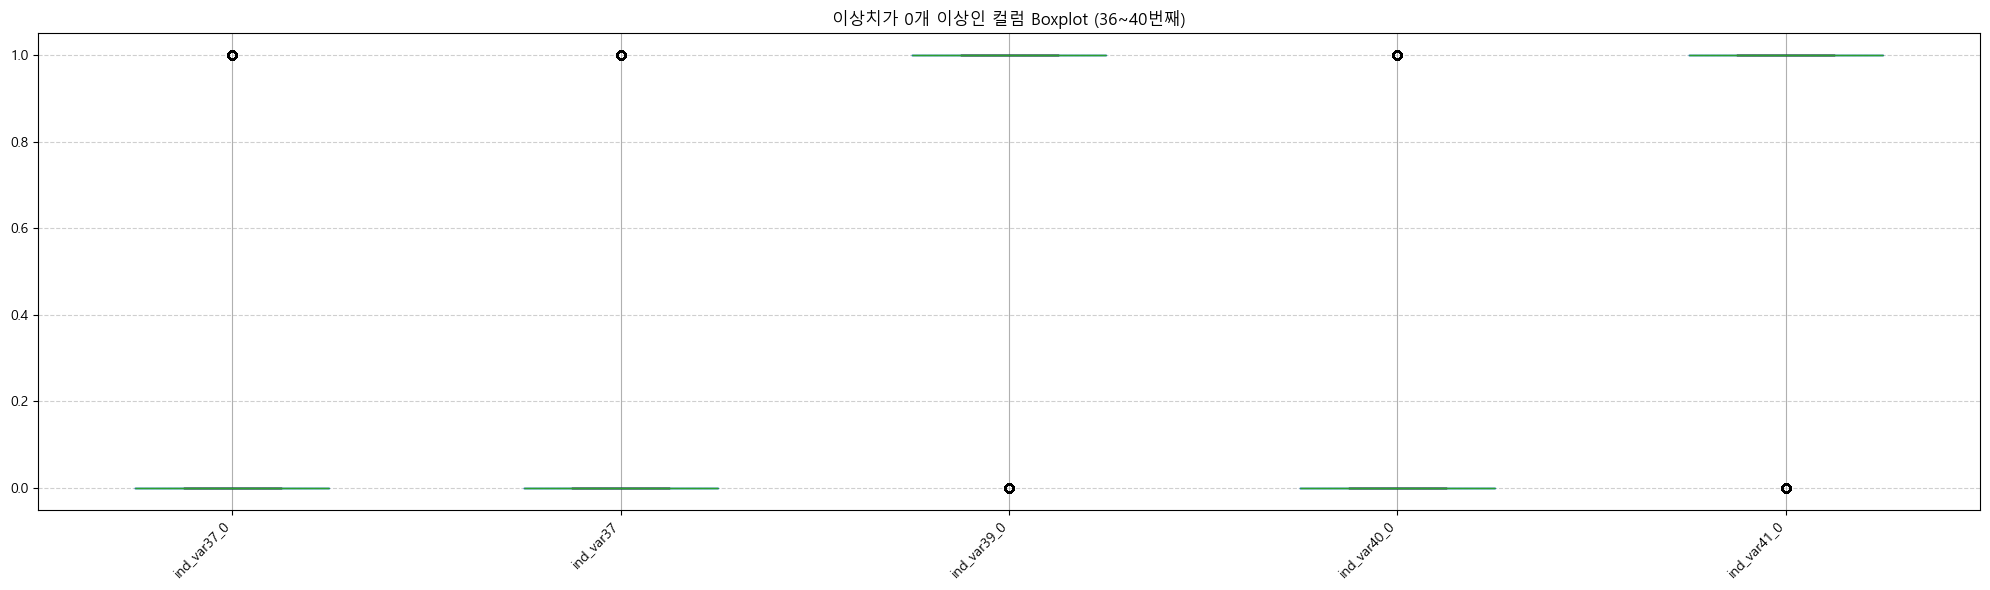

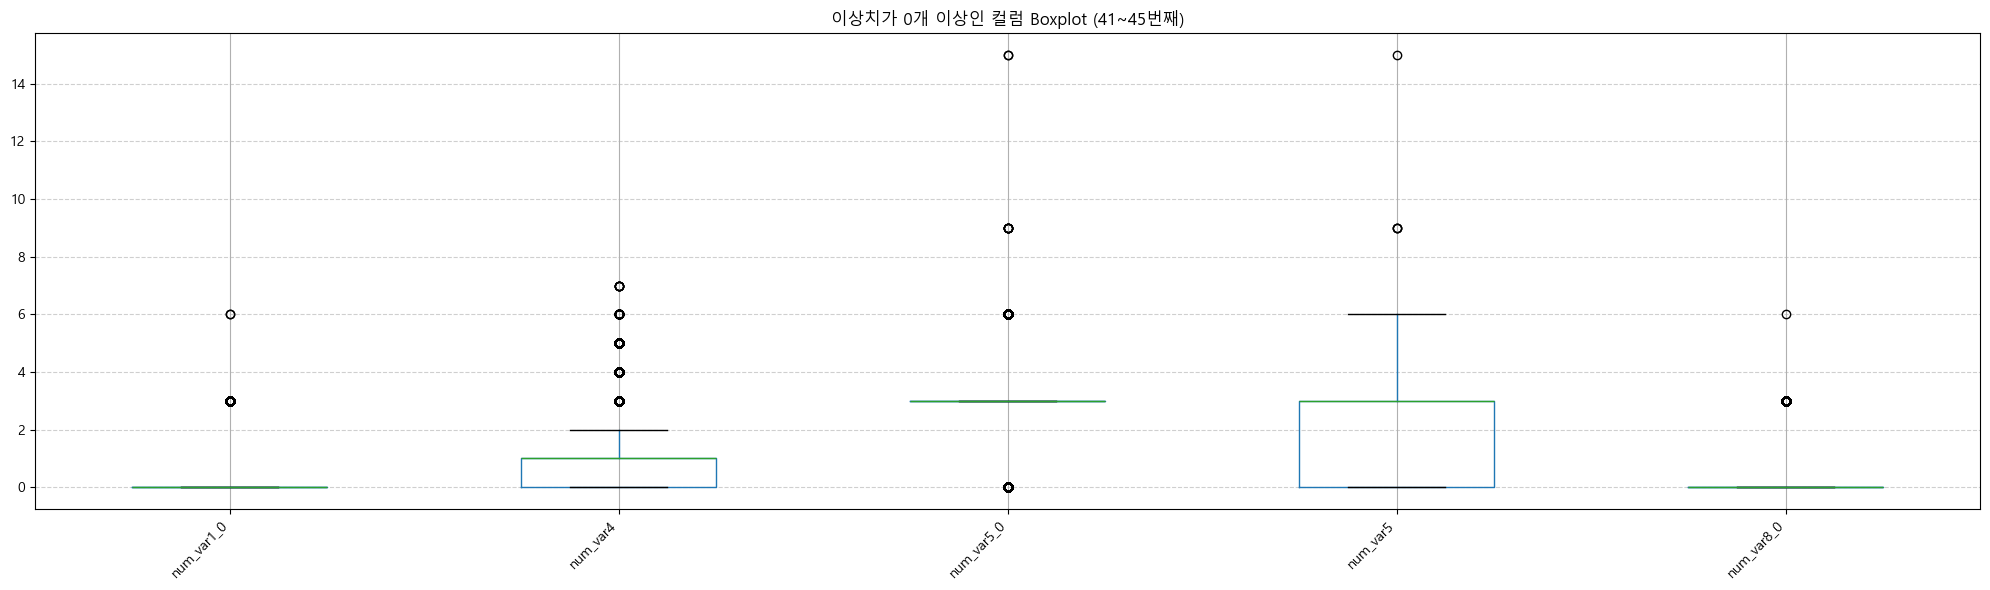

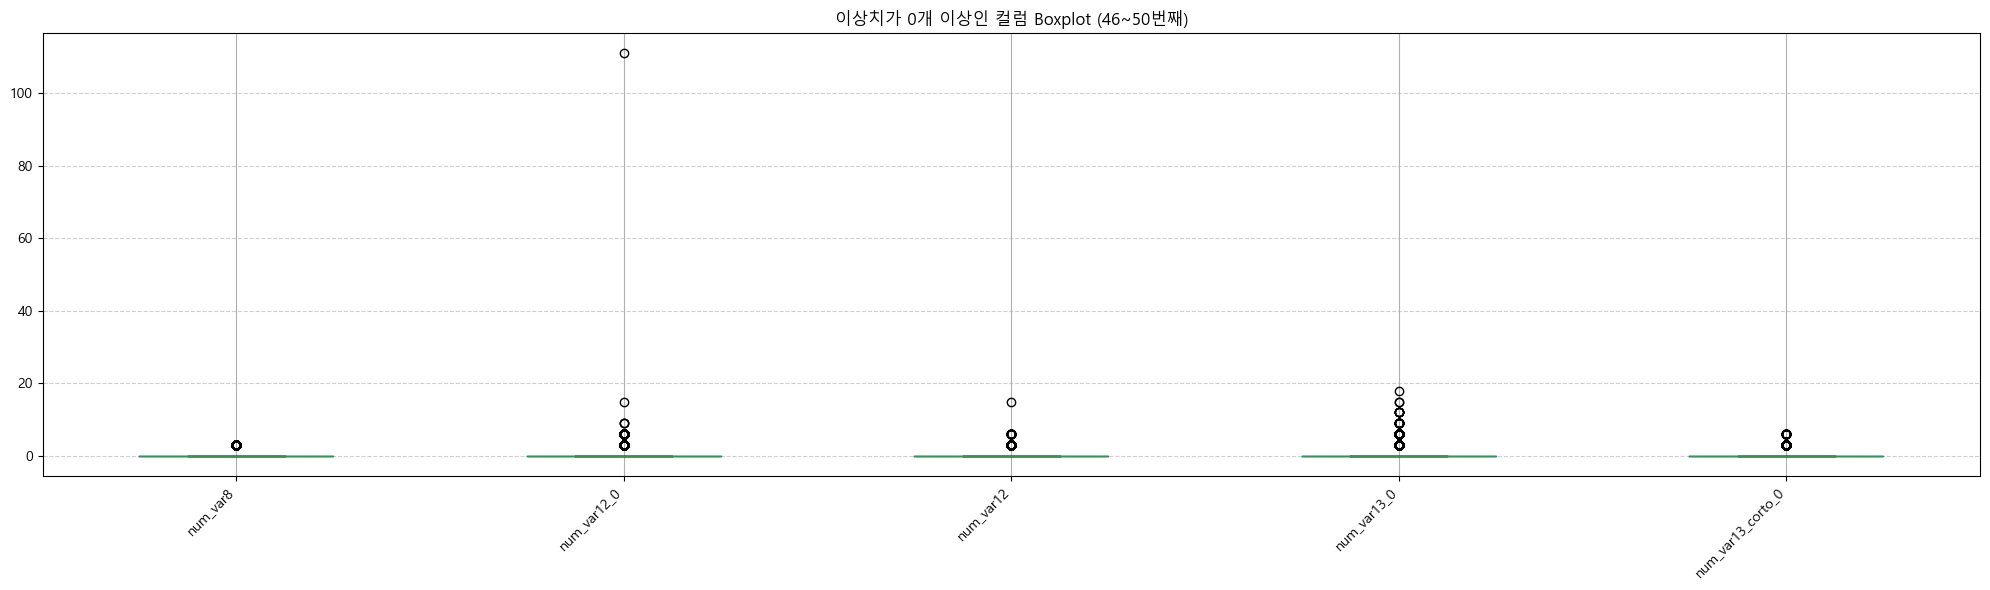

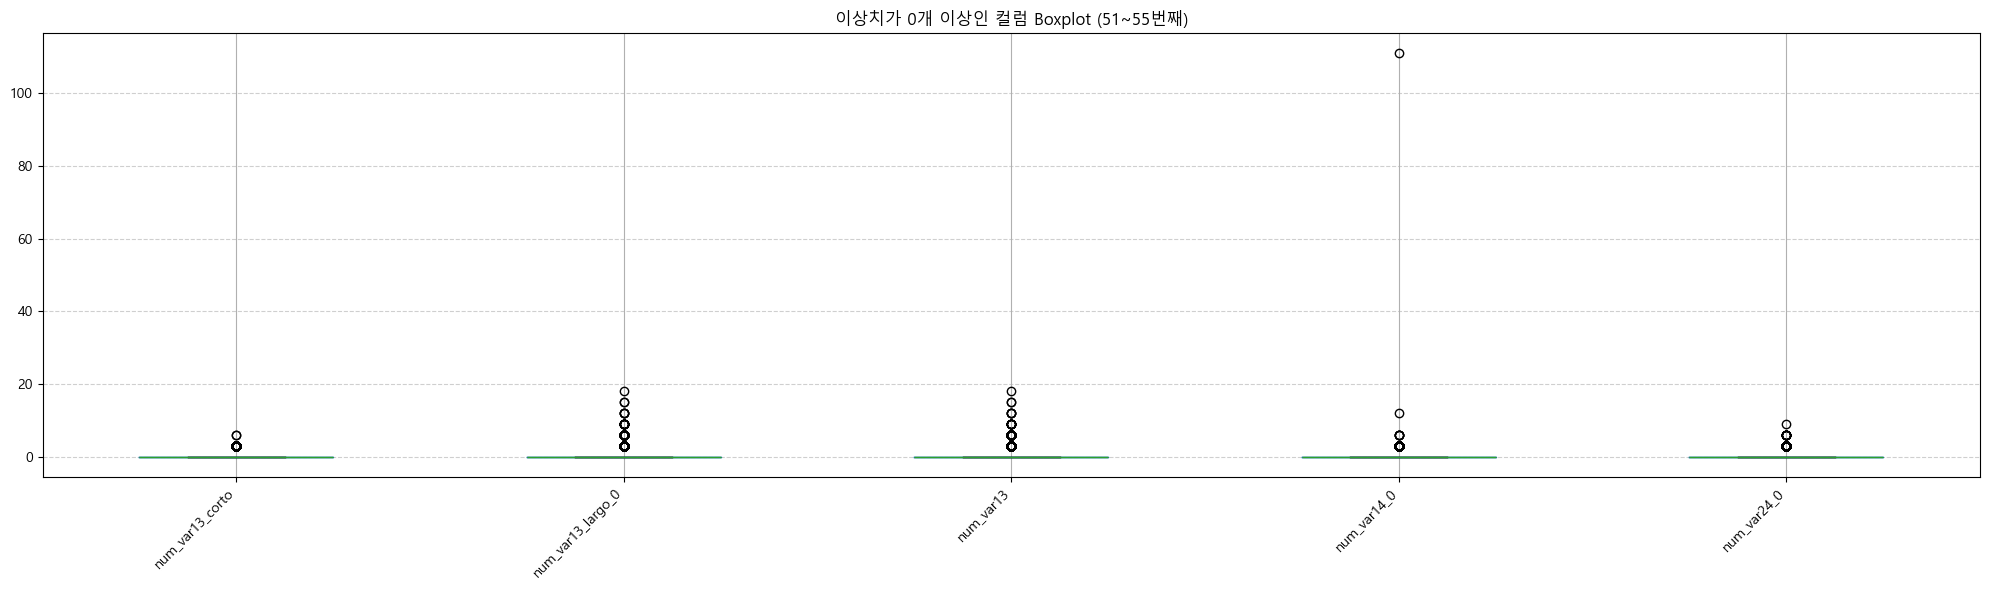

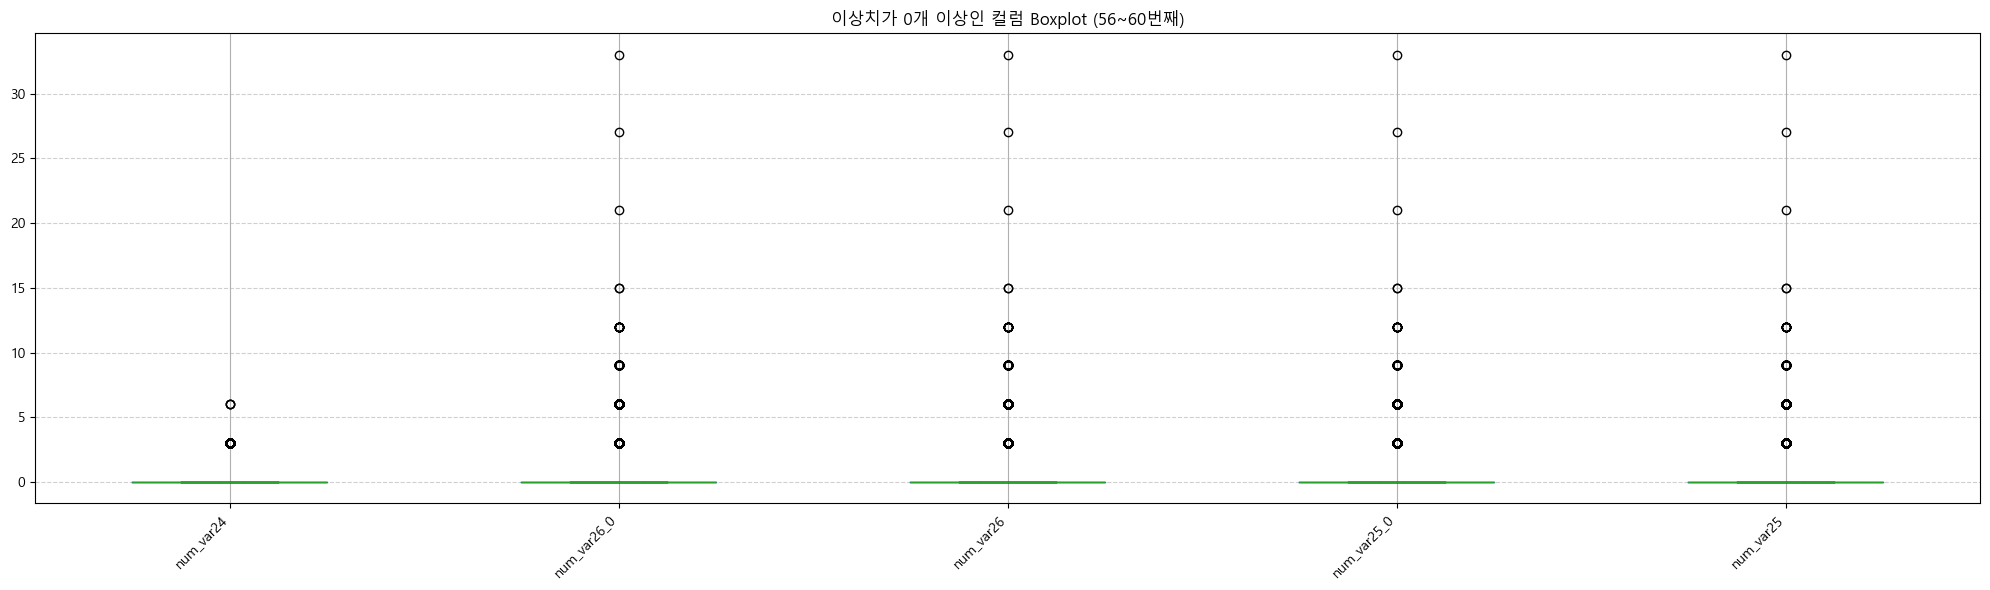

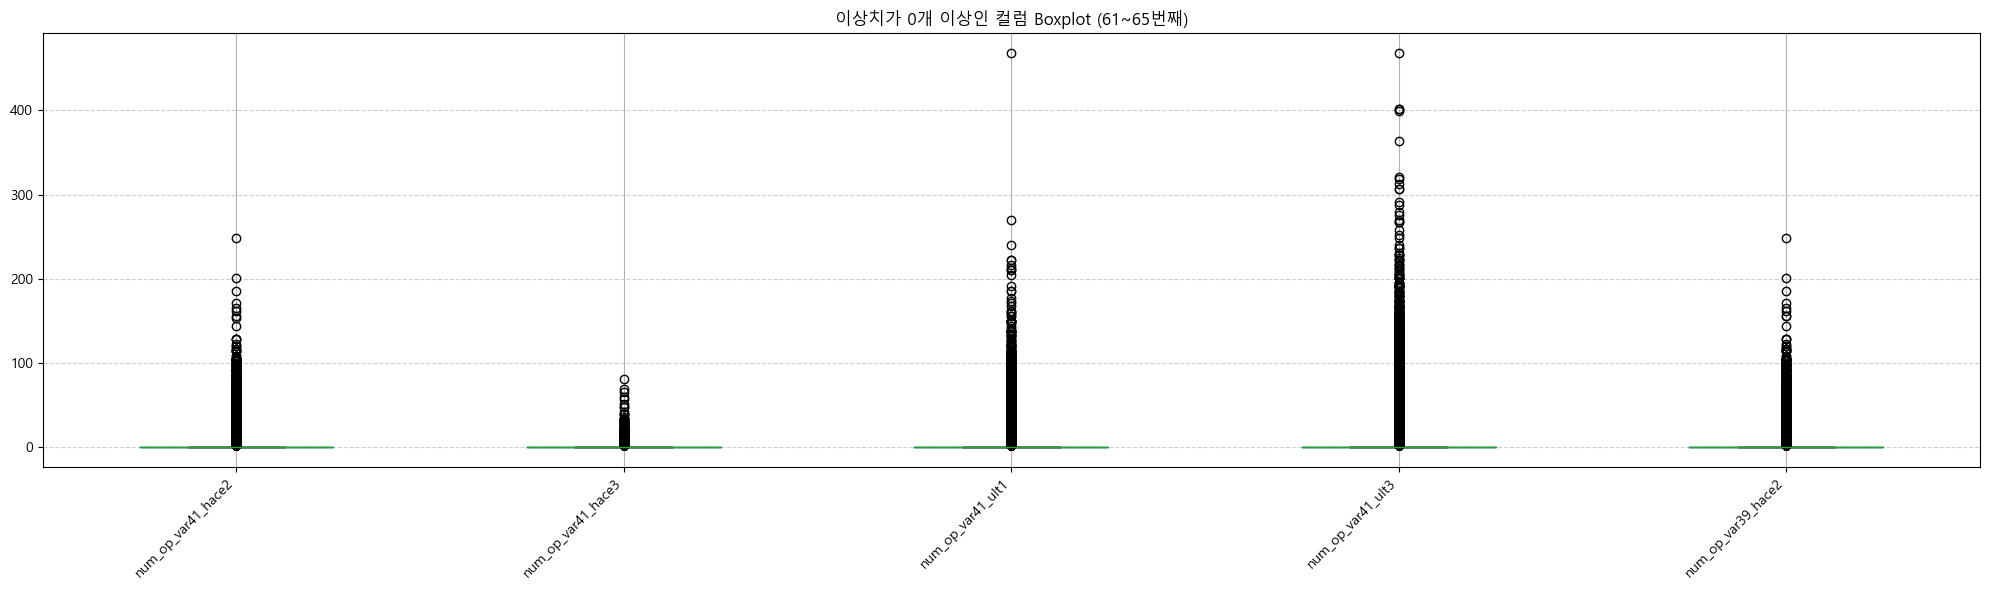

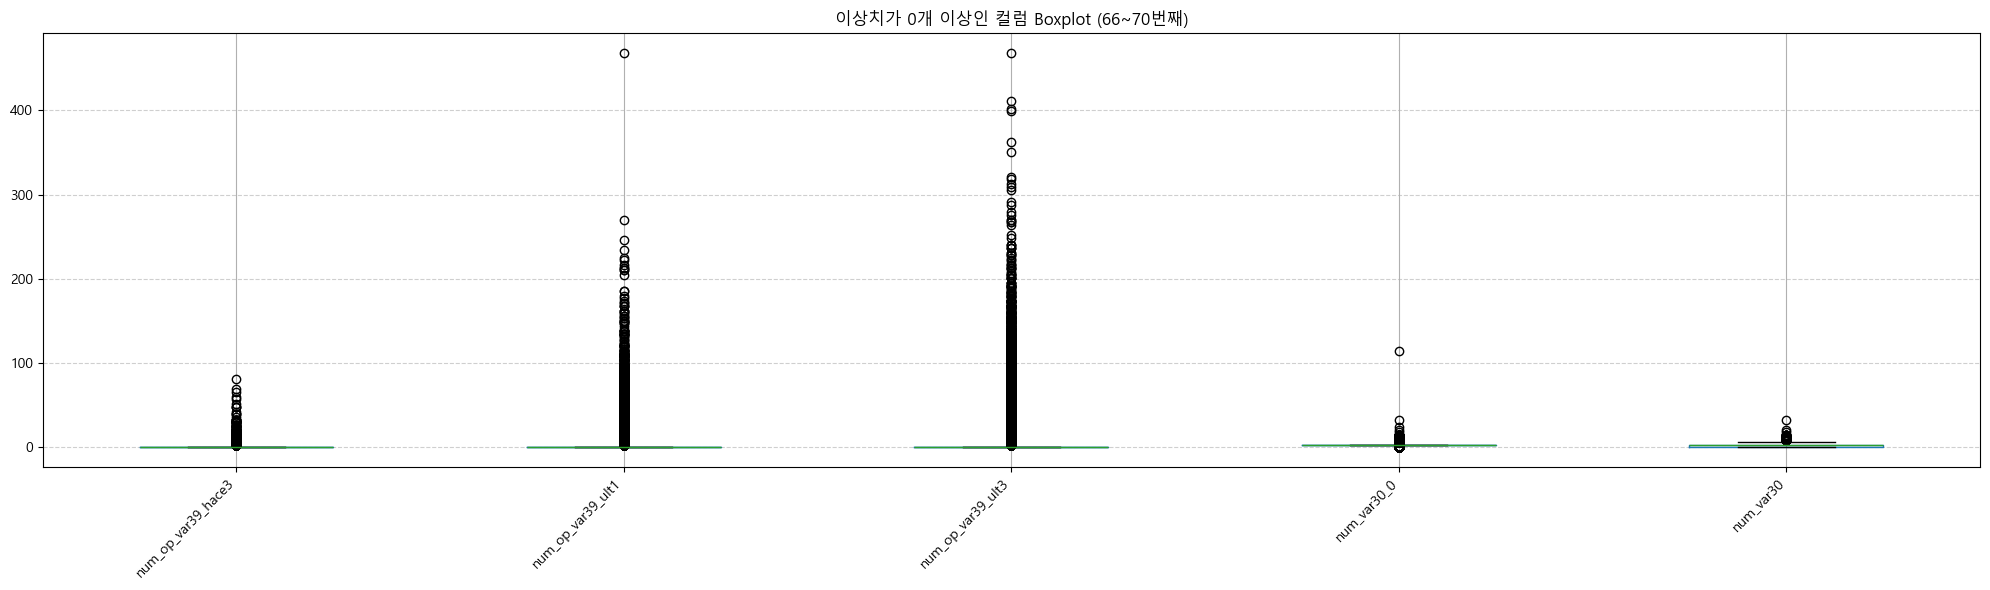

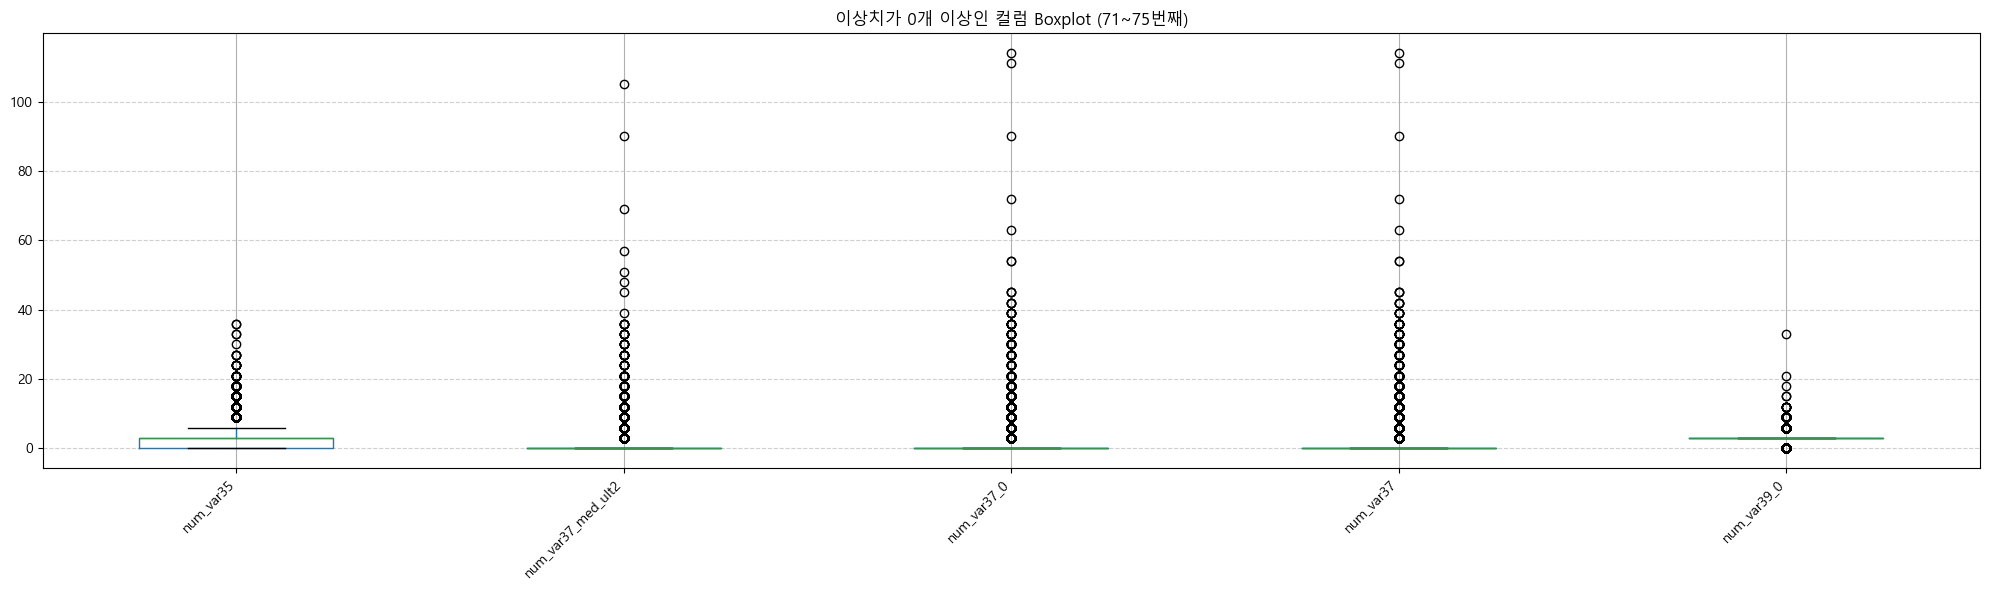

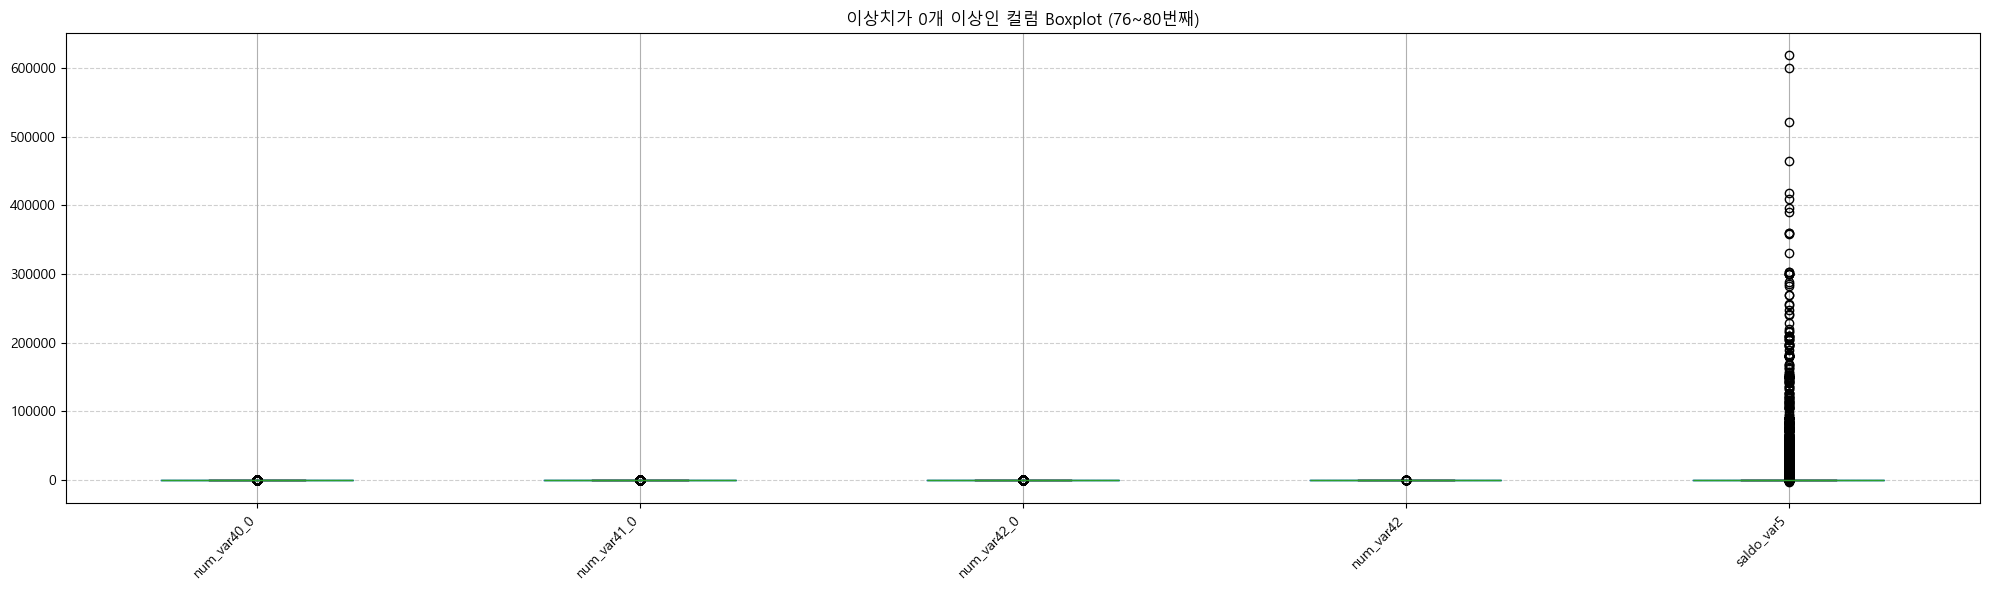

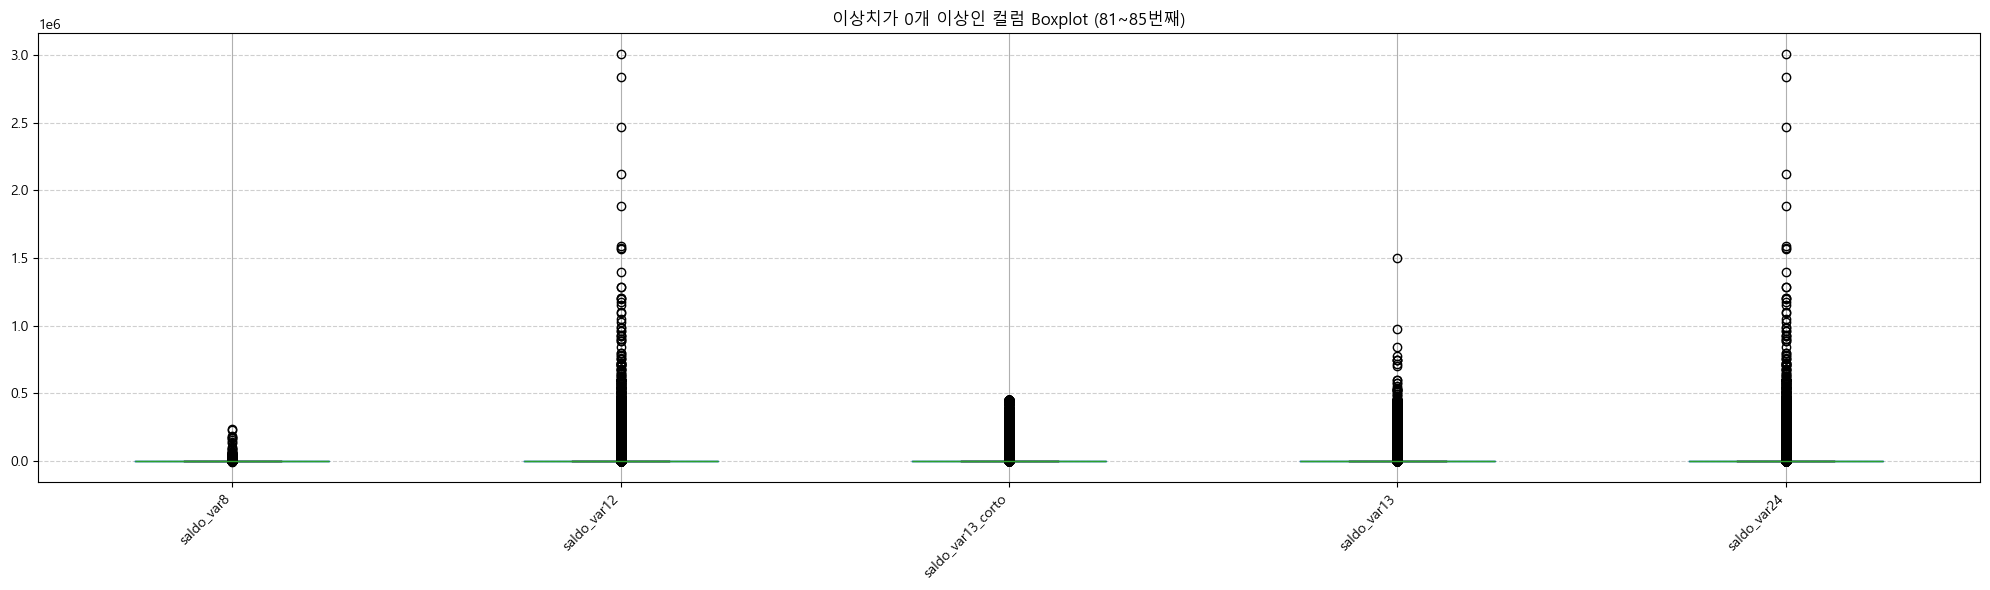

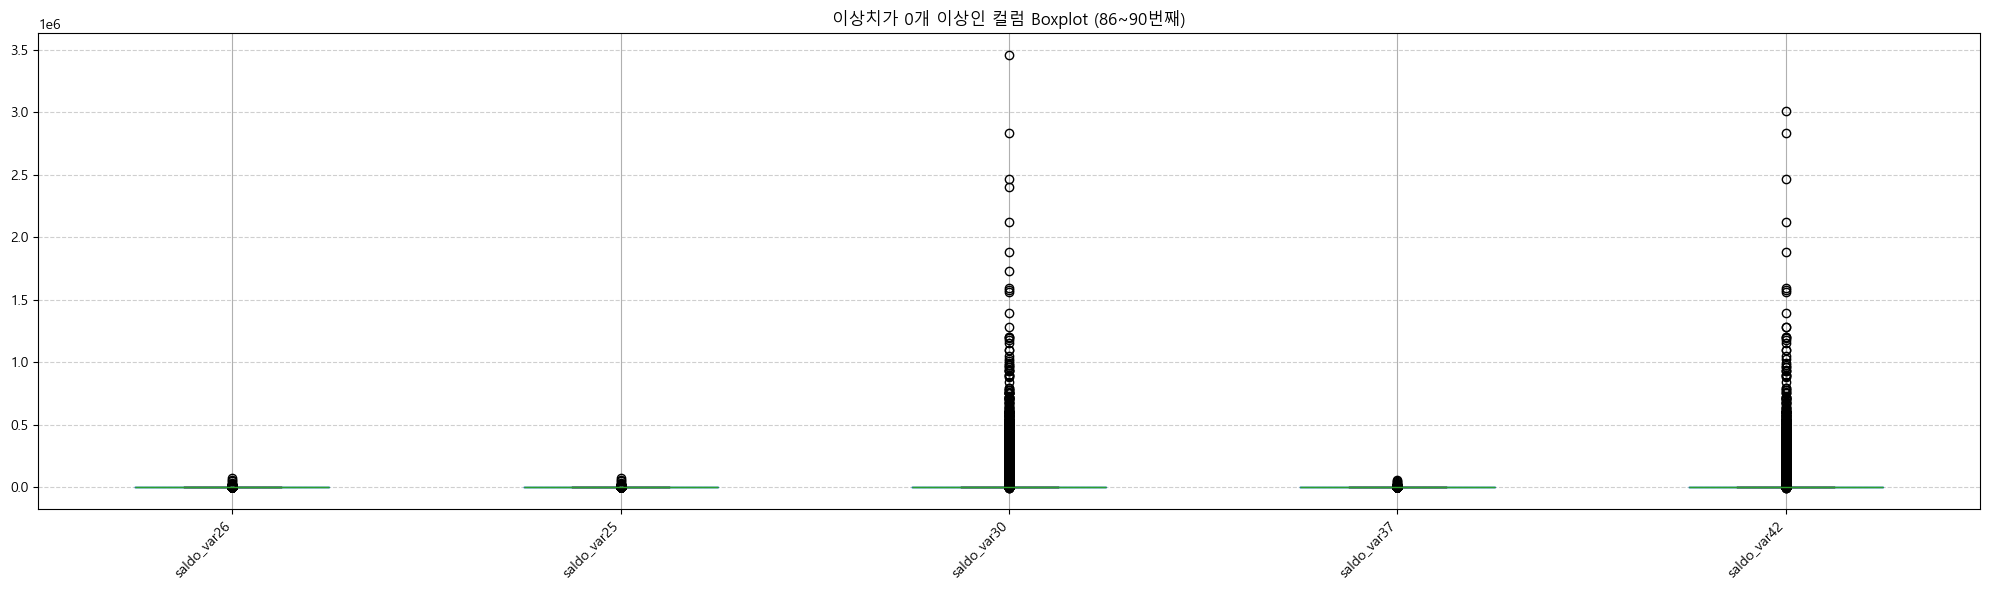

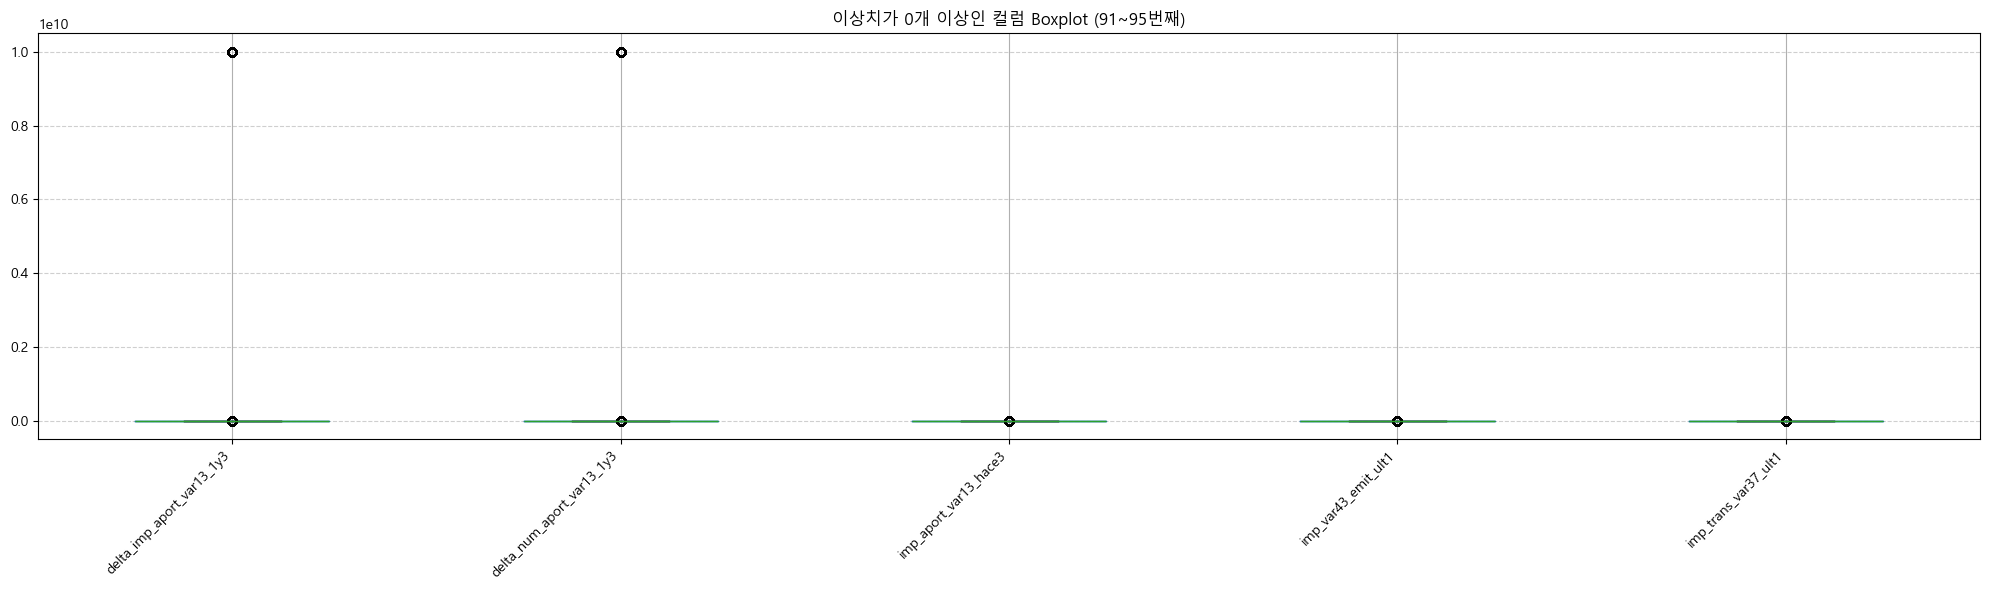

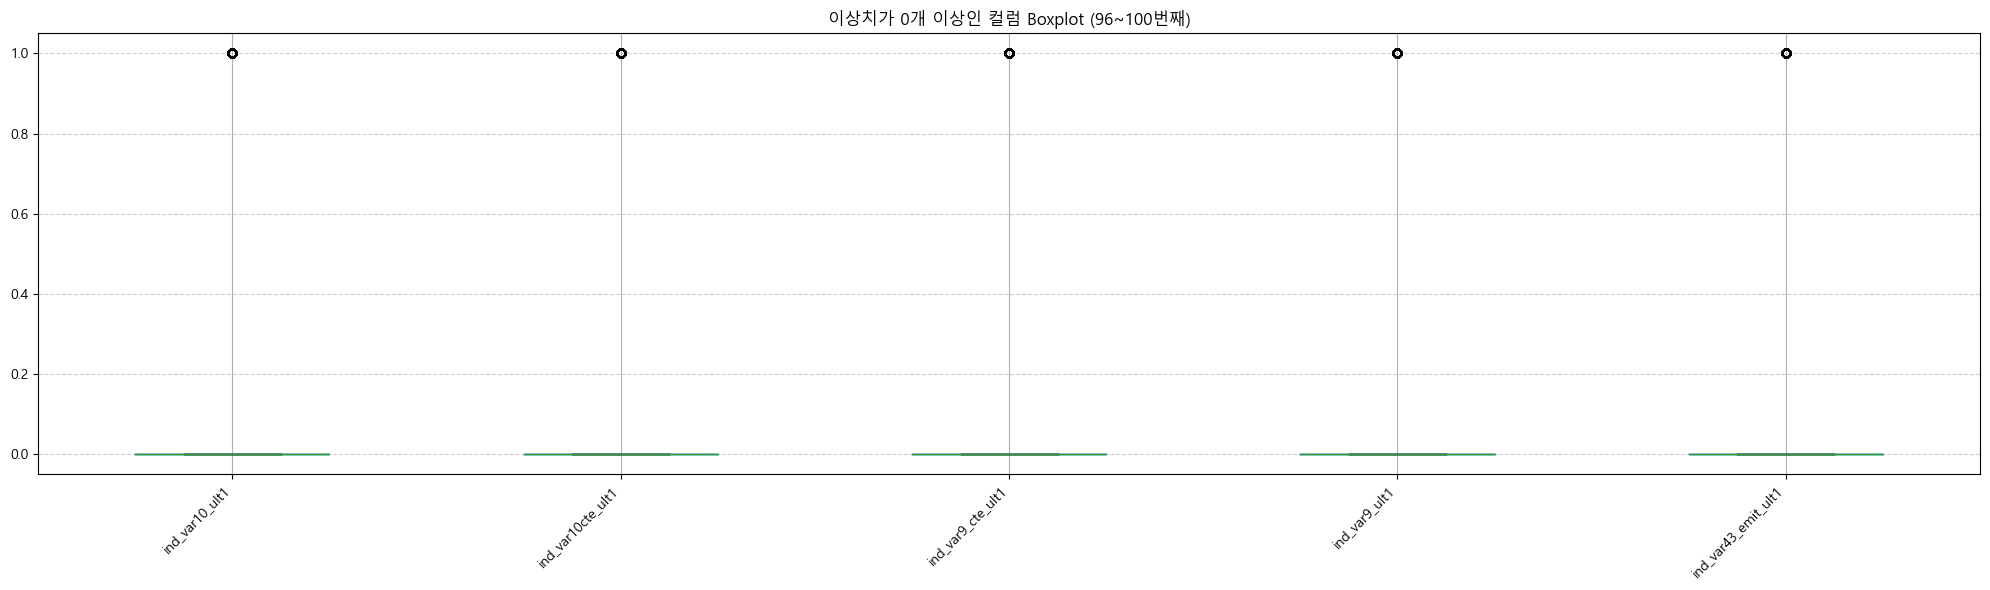

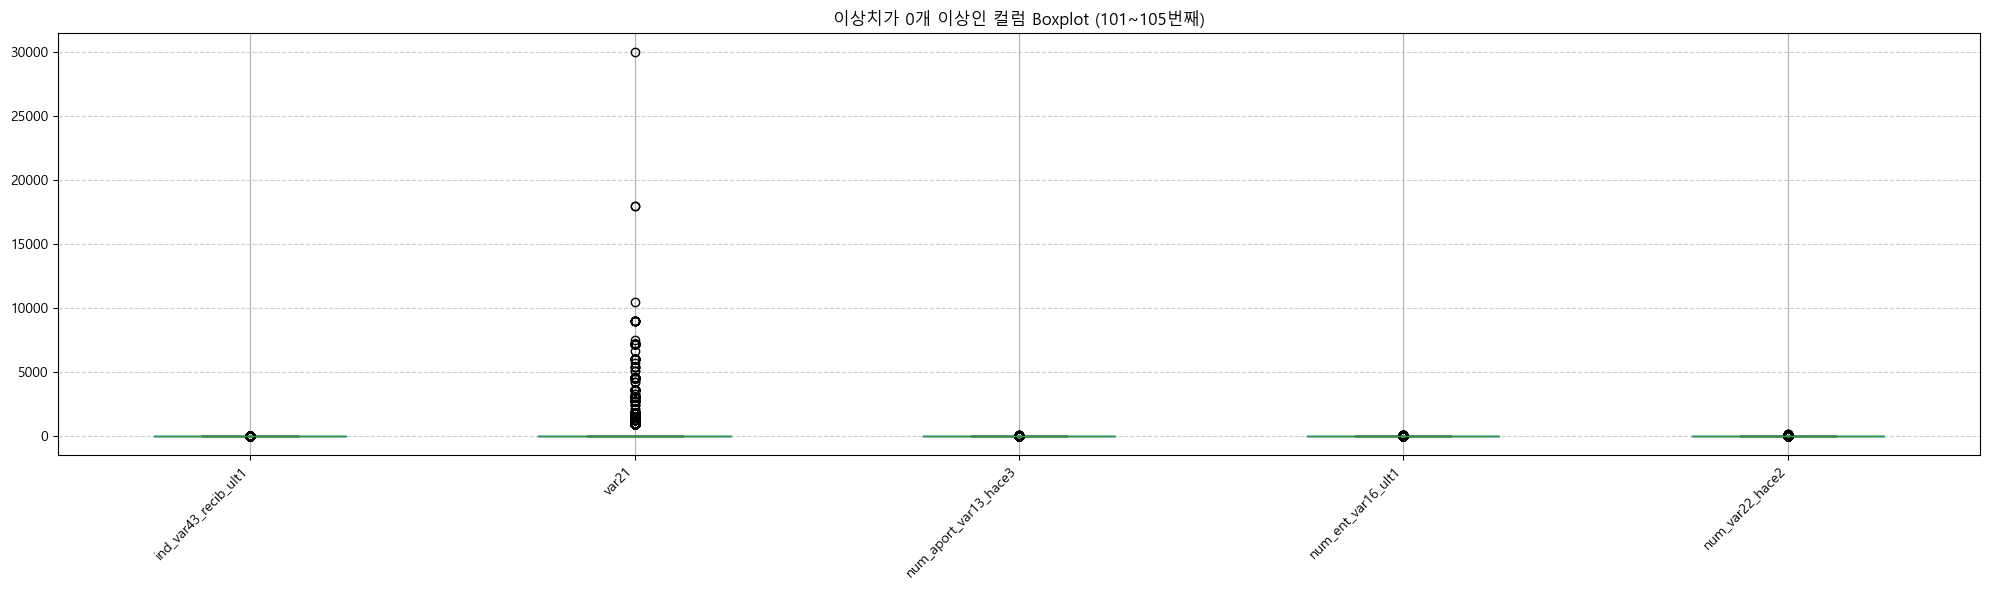

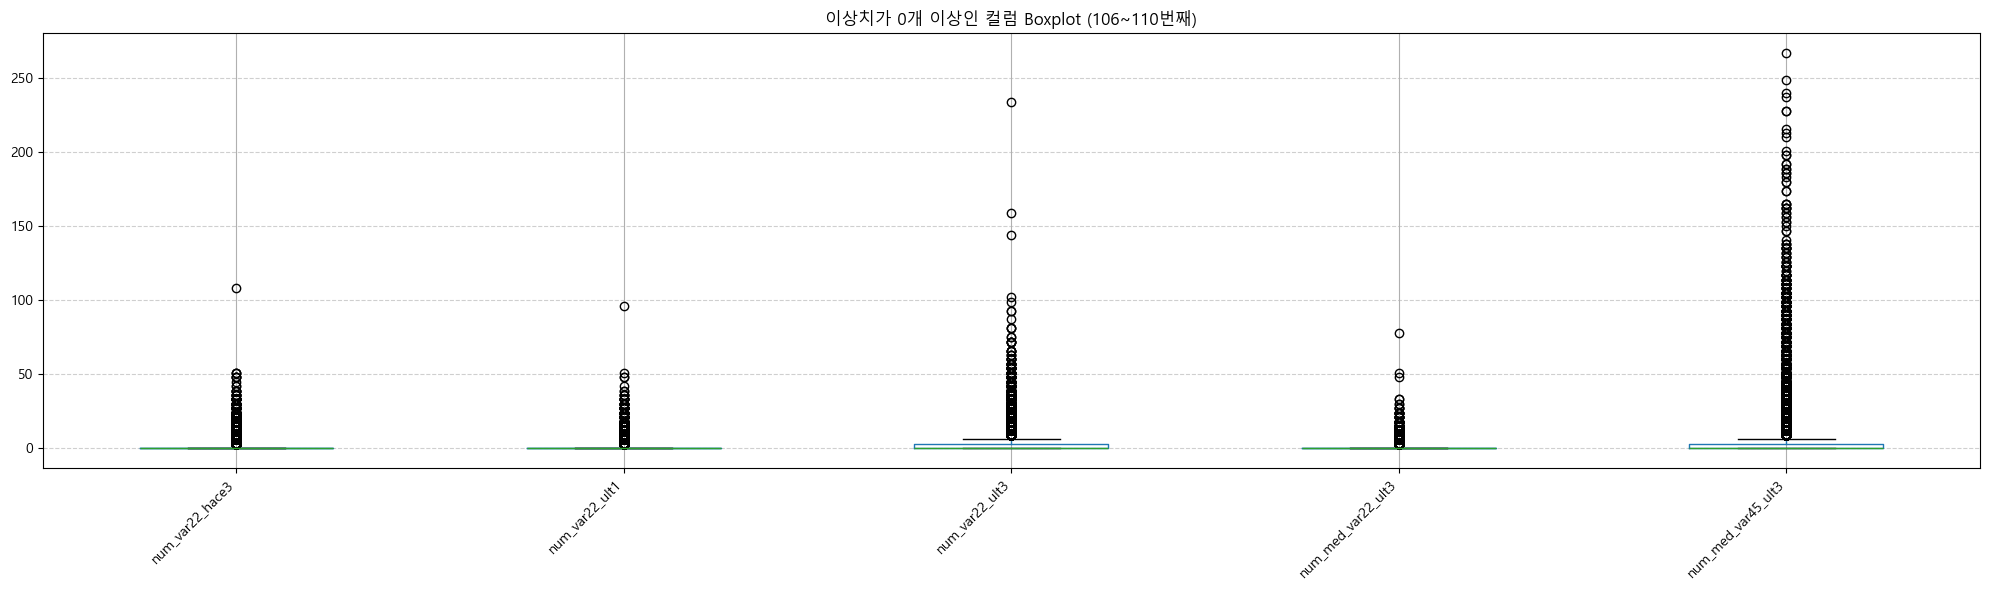

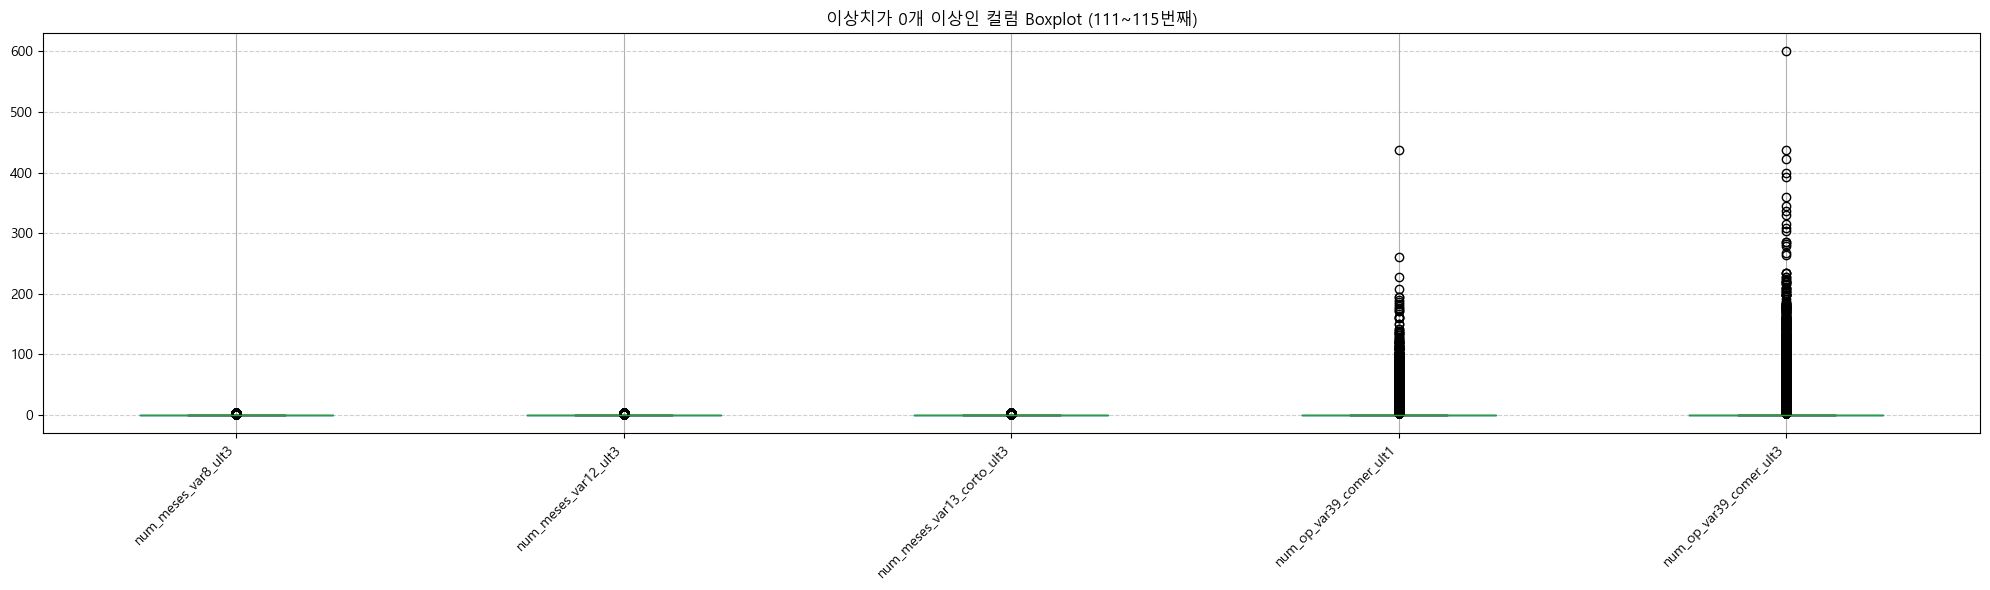

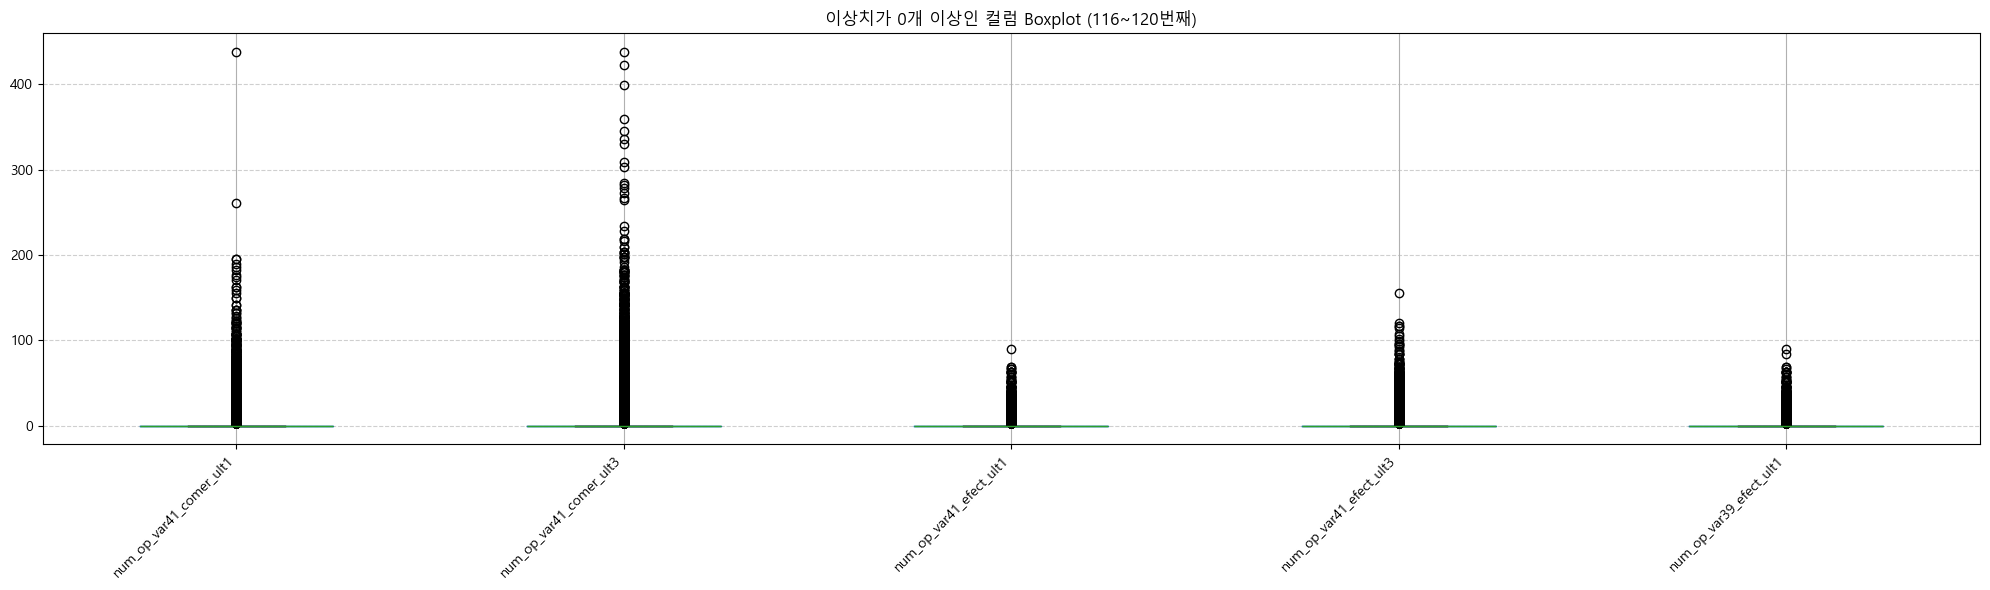

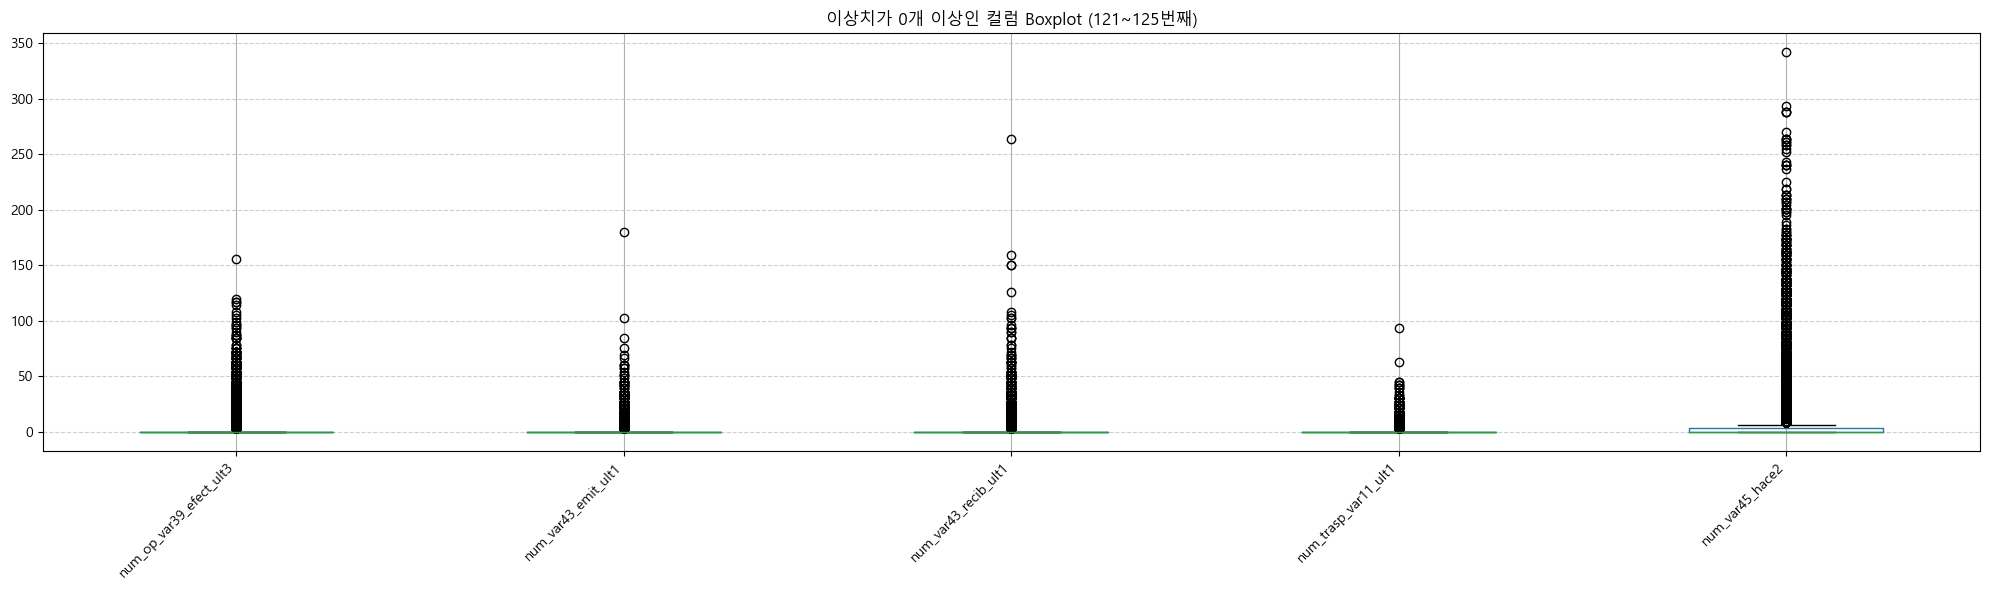

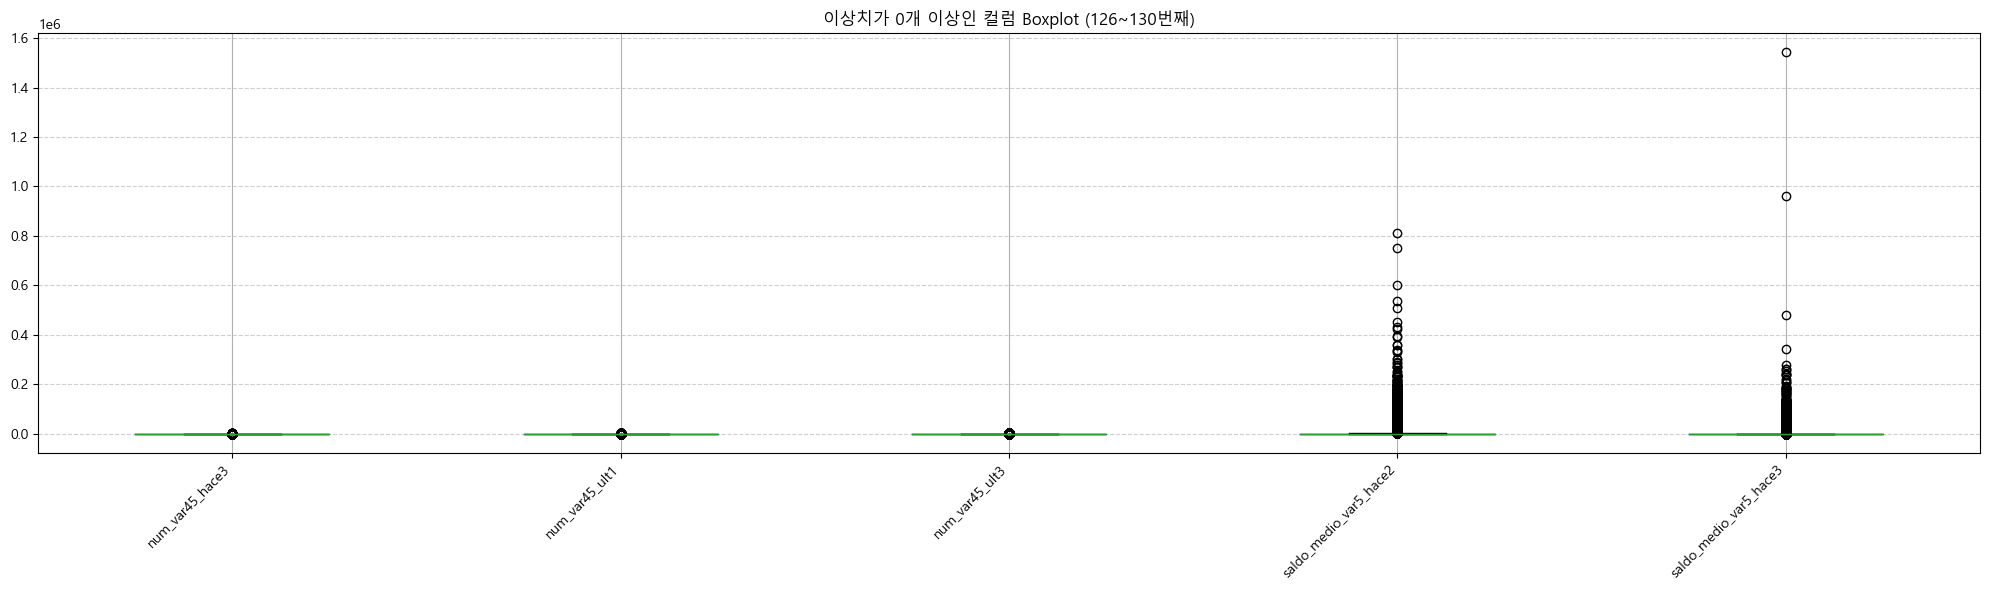

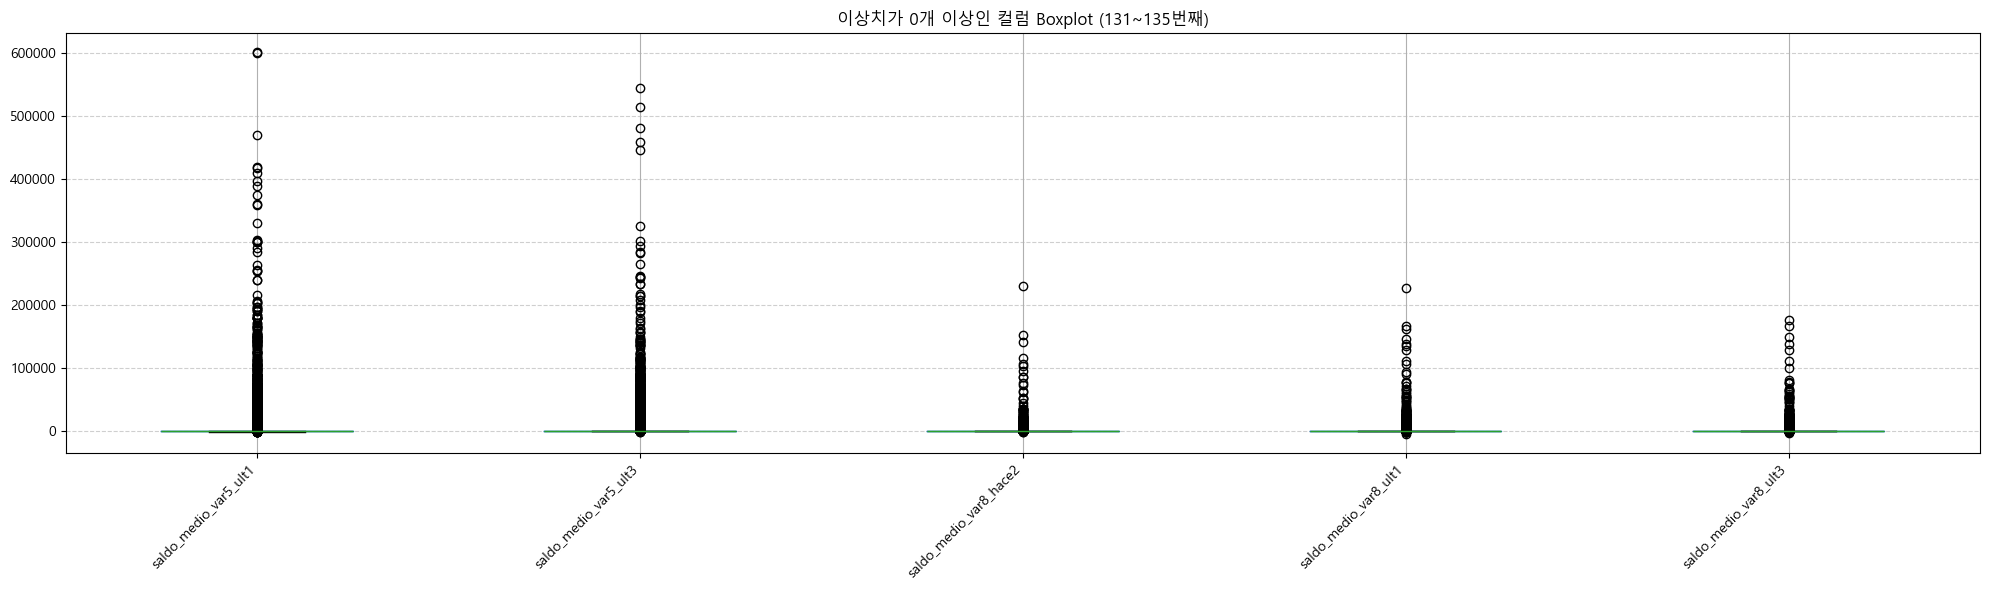

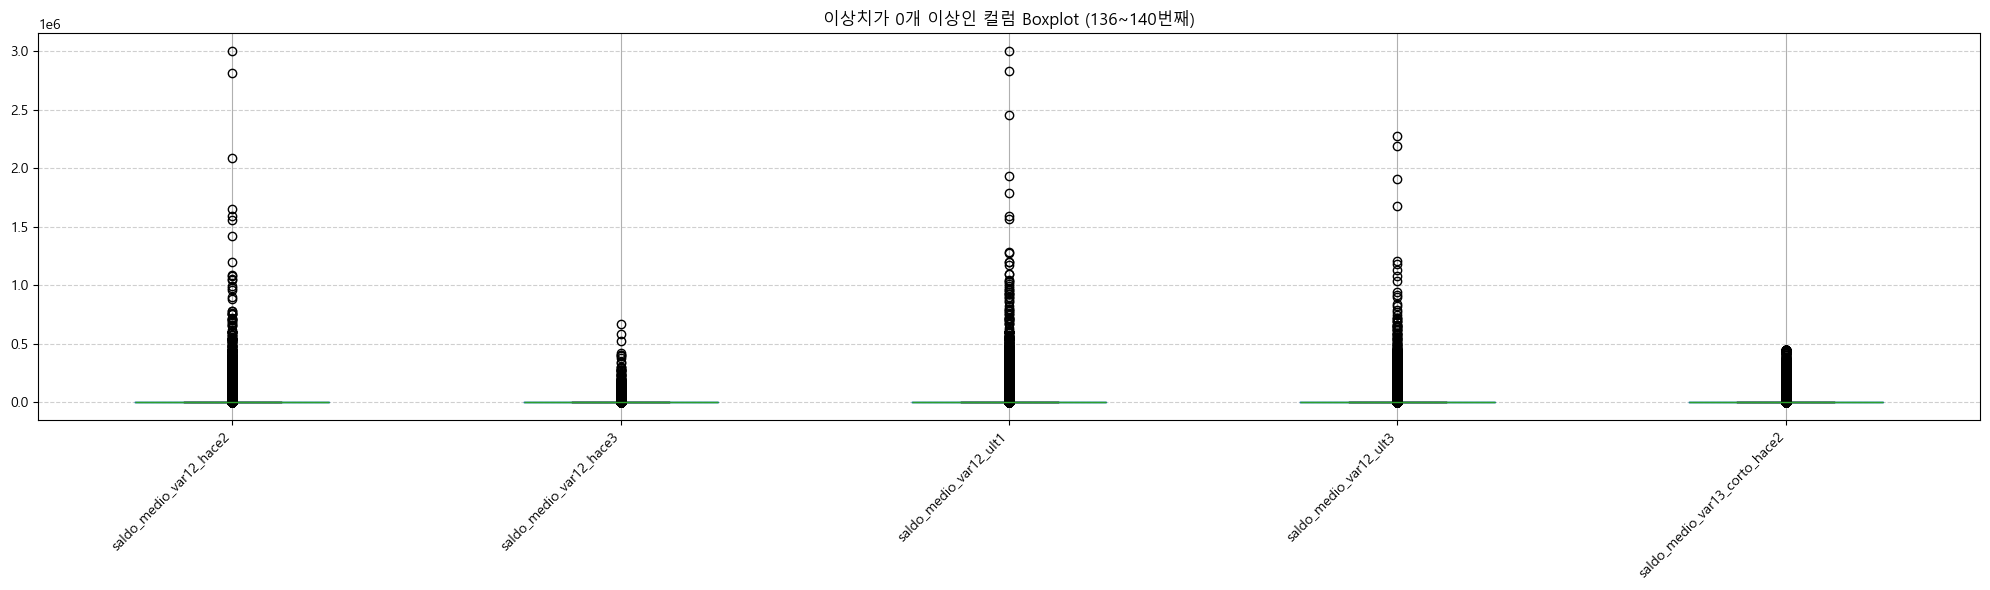

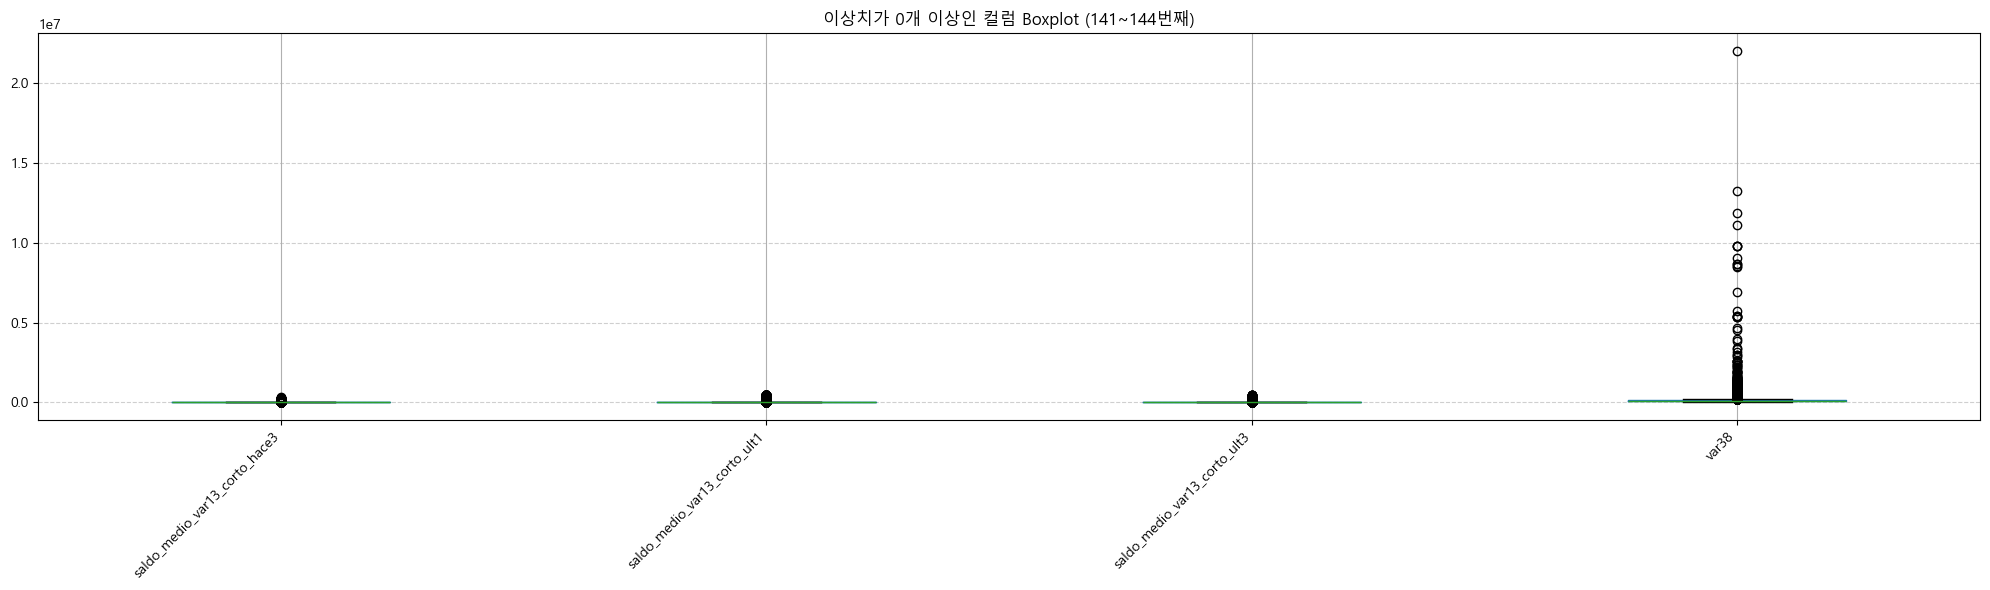

In [16]:
# 6. 10개씩 나눠서 Boxplot 시각화
chunk_size = 5
for i in range(0, len(selected_cols), chunk_size):
    chunk = selected_cols[i:i + chunk_size]
    
    plt.figure(figsize=(20, 6))
    df[chunk].boxplot()
    plt.title(f"이상치가 {ncnt}개 이상인 컬럼 Boxplot ({i+1}~{i+len(chunk)}번째)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
